In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import hmean
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.dates as mdates
from scipy.interpolate import UnivariateSpline
import itertools
import gsw
from scipy.optimize import minimize
from scipy.interpolate import interp1d

In [81]:
def process_data(filepath):    
    # Load the CSV file into a DataFrame
    data_df = pd.read_csv(filepath)
    
    # Define constants for the number of header rows and the row indicating the start of data
    NUM_HEADER_ROWS = 14
    DATA_START_MARKER = "# Data"
    
    # Separate header rows and data rows
    header_rows = data_df.iloc[:NUM_HEADER_ROWS]
    data_rows = data_df[data_df["Code"] != DATA_START_MARKER]
    
    # Create a dictionary to store DataFrames for each code
    dataframes_dict = {}
    
    # Iterate through the header rows
    for _, row in header_rows.iterrows():
        # Extract the code and headers for this code
        code, *headers = row.dropna().values
        
        # Rename the columns in a temporary DataFrame based on the extracted headers
        rename_dict = {f"V{i+1}": header for i, header in enumerate(headers)}
        temp_df = data_rows.copy()
        temp_df.rename(columns=rename_dict, inplace=True)
        
        # Get the corresponding data rows based on the code
        corresponding_data_rows = temp_df[temp_df["Code"] == code]
        
        # If there are corresponding data rows:
        if not corresponding_data_rows.empty:
            # Set the first row as the header
            corresponding_data_rows.columns = corresponding_data_rows.iloc[0].values
            # Drop the first row (now header)
            corresponding_data_rows = corresponding_data_rows.drop(corresponding_data_rows.index[0])
            dataframes_dict[code] = corresponding_data_rows
            
    return dataframes_dict

def create_nested_dictionary(filepaths):
    """
    Process multiple files and return a dictionary containing dataframes for each file.
    The keys of the outer dictionary are the last 4 digits of the csv file name.
    """
    all_dfs = {}
    
    for filepath in filepaths:
        # Extracting the identifier from the filename (using the last 4 digits)
        identifier = filepath.split("_")[-2]
        
        all_dfs[identifier] = process_data(filepath)
        
    return all_dfs

# Check and convert to datetime if not already
def ensure_datetime(df, column_name):
    if not pd.api.types.is_datetime64_any_dtype(df[column_name]):
        df[column_name] = pd.to_datetime(df[column_name])
        
def remove_outliers(df, column_name):
    """
    Removes outliers from a dataframe based on the Interquartile Range (IQR) for a given column.
    """
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Return only rows where the value is within the bounds
    return df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]

def calculate_harmonic_mean(series1, series2):
    # Drop NaN values
    combined = pd.concat([series1, series2], axis=1).dropna()
    harmonic_values = hmean(combined, axis=1)
    return pd.Series(harmonic_values, index=combined.index)


# Function to iterate over timeseries or use a constant value
def iterate_or_constant(value):
    if isinstance(value, (list, np.ndarray)):
        return value
    else:
        return itertools.repeat(value)

# Function using GSW with TEOS-10 conversions
def velocity_timeseries_TEOS10(T_series, P_series_kPa, S_series):
    velocity_series = []
    for T, P_kPa, S in zip(iterate_or_constant(T_series), iterate_or_constant(P_series_kPa), iterate_or_constant(S_series)):
        P_dbar = P_kPa * 0.1  # Convert kPa to dbar
        SA = gsw.SA_from_SP(S, P_dbar, longitude, latitude)
        CT = gsw.CT_from_t(SA, T, P_dbar)
        velocity_series.append(gsw.sound_speed(SA, CT, P_dbar))
    return velocity_series

# Function using basic T, P, S with GSW
def velocity_timeseries_basic(T_series, P_series_kPa, S_series):
    velocity_series = []
    for T, P_kPa, S in zip(iterate_or_constant(T_series), iterate_or_constant(P_series_kPa), iterate_or_constant(S_series)):
        P_dbar = P_kPa * 0.1  # Convert kPa to dbar
        velocity_series.append(gsw.sound_speed(S, T, P_dbar))
    return velocity_series

# Function using Chen and Millero equation
def velocity_timeseries_chen_millero(T_series, P_series_kPa, S_series):
    velocity_series = []
    for T, P_kPa, S in zip(iterate_or_constant(T_series), iterate_or_constant(P_series_kPa), iterate_or_constant(S_series)):
        P_bar = P_kPa * 0.01  # Convert kPa to bar
        velocity_series.append(sound_speed_chen_millero(S, T, P_bar))
    return velocity_series

# Function to perform linear regression and extrapolation
def fit_and_extrapolate(df, start_time, end_time, target_time):
    subset = df[(df['time'] >= start_time) & (df['time'] <= end_time)]
    slope, intercept, _, _, _ = linregress(
        x=subset['time'].map(pd.Timestamp.timestamp),
        y=subset['sea_water_practical_salinity']
    )
    return slope * target_time.timestamp() + intercept

def apply_tilt_correction(df_range, baseline_tag, perturb_df,
                          dist_col="Calculated Distance (m)"):
    """
    Returns a copy of df_range with a new column 'Distance_tiltcorr(m)'.
    """
    col = f"{baseline_tag}_dL"
    merged = df_range.merge(perturb_df[[col]],
                            left_on="Record Time", right_index=True, how="left")
    merged["Distance_tiltcorr(m)"] = merged[dist_col] - merged[col]
    return merged

def apply_gap_mean_shift(sdf: pd.DataFrame,
                         gap_start: pd.Timestamp,
                         gap_end: pd.Timestamp,
                         pre_hours: int = 24,
                         post_hours: int = 24,
                         col: str = 'corrected_salinity',
                         overwrite: bool = True) -> pd.DataFrame:
    """
    Drops rows in [gap_start, gap_end) and shifts all rows with time >= gap_end
    by (mean_before - mean_after), where means are computed over
    [gap_start - pre_hours, gap_start) and [gap_end, gap_end + post_hours).
    """
    sdf = sdf.copy()
    # 1) drop gap rows
    in_gap = (sdf['time'] >= gap_start) & (sdf['time'] < gap_end)
    sdf = sdf[~in_gap].reset_index(drop=True)

    # 2) compute means
    pre_mask  = (sdf['time'] >= (gap_start - pd.Timedelta(hours=pre_hours))) & (sdf['time'] < gap_start)
    post_mask = (sdf['time'] >= gap_end) & (sdf['time'] < (gap_end + pd.Timedelta(hours=post_hours)))

    pre_vals  = sdf.loc[pre_mask, col].dropna()
    post_vals = sdf.loc[post_mask, col].dropna()

    if len(pre_vals) == 0 or len(post_vals) == 0:
        raise ValueError("Not enough data in pre/post windows to compute means. "
                         "Increase pre_hours/post_hours or adjust gap bounds.")

    pre_mean  = float(pre_vals.mean())
    post_mean = float(post_vals.mean())
    shift_amt = pre_mean - post_mean

    # 3) apply constant shift to all samples at/after gap_end
    after = sdf['time'] >= gap_end
    if overwrite:
        # keep a backup, then overwrite the main column
        sdf[col + '_before_gapfix'] = sdf[col].copy()
        sdf.loc[after, col] = sdf.loc[after, col] + shift_amt
    else:
        sdf[col + '_gapfix'] = sdf[col]
        sdf.loc[after, col + '_gapfix'] = sdf.loc[after, col + '_gapfix'] + shift_amt

    # print diagnostics
    print(f"[Gap fix] {gap_start} → {gap_end} | pre_mean={pre_mean:.5f} PSU, "
          f"post_mean={post_mean:.5f} PSU, applied shift={shift_amt:+.5f} PSU, "
          f"rows_dropped={int(in_gap.sum())}")

    return sdf

def parse_to_dataframe(data):
    lines = data.split('\n')
    parsed_data = [line.split() for line in lines if line]
    df = pd.DataFrame(parsed_data, columns=['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second', 'Value'])
    df['DateTime'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second']])
    df['Value'] = pd.to_numeric(df['Value'])
    df.drop(['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second'], axis=1, inplace=True)
    return df

# Function to find the closest time in the DataFrame to a given discrete point
def find_closest_time(df, target_time):
    absolute_difference = abs(df['time'] - target_time)
    closest_index = absolute_difference.idxmin()
    return df.loc[closest_index]

# Extrapolation function using linregress
def fit_and_extrapolate(df, start_time, end_time, target_time):
    subset = df[(df['time'] >= start_time) & (df['time'] <= end_time)]
    slope, intercept, _, _, _ = linregress(
        x=subset['time'].map(pd.Timestamp.timestamp),
        y=subset['adjusted_salinity']
    )
    return slope * target_time.timestamp() + intercept

def _interp_unique(df, t):
    """Interpolate Pitch/Roll onto timeline t, after dropping dup stamps."""
    tidy = (df.set_index("Record Time")
              .sort_index()
              .loc[lambda x: ~x.index.duplicated(keep="first")])
    return (tidy.reindex(t)
                .interpolate(limit_direction="both")
                .astype(float))


def _to_enu(dx, dy, heading_deg):
    h = np.radians(heading_deg)
    east  = dx*np.sin(h) + dy*np.cos(h)
    north = dx*np.cos(h) - dy*np.sin(h)
    return east, north

def _unit(lat1, lon1, lat2, lon2):
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    mlat = np.radians((lat1 + lat2)/2)
    de, dn = dlon*np.cos(mlat)*R_EARTH, dlat*R_EARTH
    L = np.hypot(de, dn)
    return de/L, dn/L           # EN components of unit vector

# Optimization function
def optimize_tidal_influence(params, tidal_df, pressure_df):
    amplitude, rho = params
    adjusted_tidal = amplitude * tidal_df['Value']
    tidal_df['Adjusted Value'] = adjusted_tidal
    interpolated_tidal = tidal_df.reindex(pressure_df.index, method='nearest')['Adjusted Value']
    corrected_pressure = pressure_df['Pressure (kPa)'] - (rho * 9.81 * interpolated_tidal) * 0.001
    return np.var(corrected_pressure)


# Create a function to interpolate velocity
def interpolate_velocity(time_series, velocity_df):
    # Convert 'Record Time' to numeric for interpolation
    velocity_df['Record Time'] = pd.to_datetime(velocity_df['Record Time'])
    time_numeric = velocity_df['Record Time'].astype('int64')
    
    # Interpolator function
    interpolator = interp1d(time_numeric, velocity_df['SoundSpeed'], 
                            fill_value='extrapolate', bounds_error=False)
    
    # Apply interpolation
    return interpolator(pd.to_datetime(time_series).astype('int64'))


In [82]:
import pandas as pd

baseline_perturb = pd.read_pickle("src/output/baseline_perturb.pkl")
combined_df2 = pd.read_pickle("src/output/combined_df2.pkl")
combined_df3 = pd.read_pickle("src/output/combined_df3.pkl")
combined_df4 = pd.read_pickle("src/output/combined_df4.pkl")
harmonic_df_dict = pd.read_pickle("src/output/harmonic_df_dict.pkl")


In [83]:
# List of filepaths to process
filepaths = [
    "Data_230912111909_East_006870_2502_.csv",
    "Data_230912112033_West_006874_2503_.csv",
    "Data_230913091309_North_00687A_2504_.csv"
]

# Process the files again using the updated outlier removal function
df_dict = create_nested_dictionary(filepaths)

# Convert the 'SoundSpeed (m/s)' column to a numeric data type and then proceed with the outlier removal and dataframe creation using IQR
result_dfs = {}
identifiers = ['2502', '2503', '2504']

for identifier in identifiers:
    ssp_df = df_dict[identifier]['SSP'].copy()
    ssp_df['SoundSpeed (m/s)'] = pd.to_numeric(ssp_df['SoundSpeed (m/s)'], errors='coerce')
    cleaned_df = remove_outliers(ssp_df, 'SoundSpeed (m/s)')
    result_df = cleaned_df[['Record Time', 'SoundSpeed (m/s)']]
    result_df = result_df.rename(columns={'SoundSpeed (m/s)': 'SoundSpeed'})
    result_dfs[identifier] = result_df

# Converting the 'Record Time' column in the dataframes within result_dfs to datetime format
for identifier, df in result_dfs.items():
    df['Record Time'] = pd.to_datetime(df['Record Time'])

# Setting the 'SoundSpeed' values of 2503 to NaN
result_dfs['2503']['SoundSpeed'] = np.nan



/tmp/ipykernel_1893829/1507283314.py:3: DtypeWarning: Columns (4,6,7,8,9,10,11,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  data_df = pd.read_csv(filepath)
/tmp/ipykernel_1893829/1507283314.py:3: DtypeWarning: Columns (4,6,8,9,10,11,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  data_df = pd.read_csv(filepath)
/tmp/ipykernel_1893829/1507283314.py:3: DtypeWarning: Columns (6,7,8,9,10,11,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  data_df = pd.read_csv(filepath)
/tmp/ipykernel_1893829/4053753169.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Record Time'] = pd.to_datetime(df['Record Time'])
/tmp/ipykernel_1893829/4053753169.py:25: UserWarning: Could not infer format, so each element will be par

## Range Calculation

/tmp/ipykernel_1893829/709272540.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  plt.scatter(pd.to_datetime(bsl_2503_df['Record Time']),bsl_2503_df['Range(ms)'],s=1)


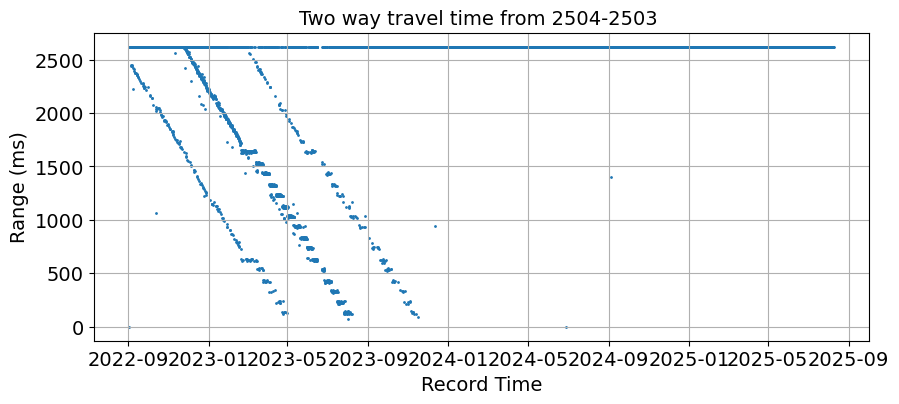

In [84]:
bsl_df = df_dict['2504']['BSL']
bsl_df['RangeAddress'] = bsl_df['RangeAddress'].astype(int).astype(str)
bsl_df['Range(ms)'] = pd.to_numeric(bsl_df['Range(ms)'], errors='coerce')
bsl_df['TAT(ms)'] = pd.to_numeric(bsl_df['TAT(ms)'], errors='coerce')
bsl_2503_df = bsl_df[bsl_df['RangeAddress'] == '2503'].copy()

plt.figure(figsize=(10, 4))
plt.scatter(pd.to_datetime(bsl_2503_df['Record Time']),bsl_2503_df['Range(ms)'],s=1)
plt.title('Two way travel time from 2504-2503 ')
plt.xlabel('Record Time')
plt.ylabel('Range (ms)')
plt.grid(True)
plt.rcParams.update({'font.size': 14})
plt.show()


## Final Figures

#### 2504 to east and west

In [224]:
# Extract DataFrames based on the 'RangeAddress' column values
bsl_df = df_dict['2504']['BSL']
bsl_df['RangeAddress'] = bsl_df['RangeAddress'].astype(int).astype(str)
bsl_df['Range(ms)'] = pd.to_numeric(bsl_df['Range(ms)'], errors='coerce')
bsl_df['TAT(ms)'] = pd.to_numeric(bsl_df['TAT(ms)'], errors='coerce')
bsl_2501_df = bsl_df[bsl_df['RangeAddress'] == '2501'].copy()
bsl_2502_df = bsl_df[bsl_df['RangeAddress'] == '2502'].copy()
bsl_2503_df = bsl_df[bsl_df['RangeAddress'] == '2503'].copy()

# Calculate the IQR for the 'Range(ms)' column in bsl_2502_df
Q1 = bsl_2502_df['Range(ms)'].quantile(0.15)
Q3 = bsl_2502_df['Range(ms)'].quantile(0.85)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


total_rows1 = len(bsl_2502_df)

# Filter out outliers
filtered_bsl_2502_df = bsl_2502_df[(bsl_2502_df['Range(ms)'] >= lower_bound) & (bsl_2502_df['Range(ms)'] <= upper_bound)]
outside_values_df1 = bsl_2502_df[(bsl_2502_df['Range(ms)'] < lower_bound) | (bsl_2502_df['Range(ms)'] > upper_bound)]

# Number of rows after removing outliers
rows_after_filtering1 = len(filtered_bsl_2502_df)
# Calculate the number of outlier rows
num_outliers1 = total_rows1 - rows_after_filtering1
# Calculate the percentage of outliers
percent_outliers_2504_2502 = (num_outliers1 / total_rows1) * 100


# Convert the 'Range(ms)' column to numeric for plotting
bsl_2503_df['Range(ms)'] = pd.to_numeric(bsl_2503_df['Range(ms)'], errors='coerce')

total_rows = len(bsl_2503_df)

# Filter out data points with 'Range(ms)' values less than 2618 from the original bsl_2503_df
filtered_bsl_2503_df = bsl_2503_df[bsl_2503_df['Range(ms)'] >= 2618]
outside_values_df2 = bsl_2503_df[bsl_2503_df['Range(ms)'] < 2618]


# Convert the 'Range(ms)' column to numeric for plotting
bsl_2502_df['Range(ms)'] = pd.to_numeric(bsl_2502_df['Range(ms)'], errors='coerce')

# Creating explicit copies of the DataFrames to avoid the warning
filtered_bsl_2502_copy = filtered_bsl_2502_df.copy()
filtered_bsl_2503_copy = filtered_bsl_2503_df.copy()

# Create explicit copies to avoid the SettingWithCopyWarning
filtered_bsl_2502_copy = filtered_bsl_2502_df.copy()

ensure_datetime(filtered_bsl_2502_copy, 'Record Time')
ensure_datetime(harmonic_df_dict['2502_2504'], 'Record Time')


# Interpolate sound speed values onto the filtered_bsl_2502_copy timestamps
filtered_bsl_2502_copy['Interpolated Sound Speed'] = np.interp(
    filtered_bsl_2502_copy['Record Time'].view(np.int64),
    harmonic_df_dict['2502_2504']['Record Time'].view(np.int64),
    harmonic_df_dict['2502_2504']['HMean']
)

# Calculate distance using the interpolated sound speeds
filtered_bsl_2502_copy['Calculated Distance (m)'] = filtered_bsl_2502_copy['Interpolated Sound Speed'] * ((filtered_bsl_2502_copy['Range(ms)']-filtered_bsl_2502_copy['TAT(ms)']) / 2000)  # Dividing by 2000 to convert ms to seconds and account for two-way travel

filtered_bsl_2502_copy['Interpolated Harmonic Velocity'] = np.interp(
    filtered_bsl_2502_copy['Record Time'].view(np.int64),
    harmonic_mean_dfs['2502_2504']['Record Time'].view(np.int64),
    harmonic_mean_dfs['2502_2504']['Harmonic Mean']
)

# Calculate distance using the interpolated sound speeds
filtered_bsl_2502_copy['Harmonic Distance (m)'] = filtered_bsl_2502_copy['Interpolated Harmonic Velocity'] * ((filtered_bsl_2502_copy['Range(ms)']-filtered_bsl_2502_copy['TAT(ms)']) / 2000)  # Dividing by 2000 to convert ms to seconds and account for two-way travel

filtered_bsl_2502_copy = apply_tilt_correction(
    filtered_bsl_2502_copy, "2504-2502", baseline_perturb
)

R2504_2502 = filtered_bsl_2502_copy
#-------------------------------------------------------------------------------------------------------


# Create an explicit copy of filtered_bsl_2503_df to avoid the SettingWithCopyWarning
filtered_bsl_2503_copy = filtered_bsl_2503_df.copy()

ensure_datetime(filtered_bsl_2503_copy, 'Record Time')
ensure_datetime(harmonic_mean_dfs['2503_2504'], 'Record Time')

# Interpolate sound speed values onto the filtered_bsl_2503_copy timestamps
filtered_bsl_2503_copy['Interpolated Sound Speed'] = np.interp(
    filtered_bsl_2503_copy['Record Time'].view(np.int64),
    harmonic_df_dict['2503_2504']['Record Time'].view(np.int64),
    harmonic_df_dict['2503_2504']['HMean']
)

# Calculate distance using the interpolated sound speeds
filtered_bsl_2503_copy['Calculated Distance (m)'] = filtered_bsl_2503_copy['Interpolated Sound Speed'] * ((filtered_bsl_2503_copy['Range(ms)']-filtered_bsl_2503_copy['TAT(ms)']) / 2000)  # Dividing by 2000 to convert ms to seconds and account for two-way travel



# Interpolate Harmonic Mean Velocity onto the filtered_bsl_2503_copy timestamps
filtered_bsl_2503_copy['Interpolated Harmonic Velocity'] = np.interp(
    filtered_bsl_2503_copy['Record Time'].view(np.int64),
    harmonic_mean_dfs['2503_2504']['Record Time'].view(np.int64),
    harmonic_mean_dfs['2503_2504']['Harmonic Mean']
)

# Calculate distance using the interpolated Harmonic Mean Velocity
# Remember to divide the time (Range - TAT) by 2000 to convert ms to seconds and for two-way travel
filtered_bsl_2503_copy['Harmonic Distance (m)'] = filtered_bsl_2503_copy['Interpolated Harmonic Velocity'] * ((filtered_bsl_2503_copy['Range(ms)'] - filtered_bsl_2503_copy['TAT(ms)']) / 2000)

filtered_bsl_2503_copy = apply_tilt_correction(
    filtered_bsl_2503_copy, "2504-2503", baseline_perturb
)

R2504_2503 = filtered_bsl_2503_copy



/tmp/ipykernel_1893829/1507283314.py:57: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column_name] = pd.to_datetime(df[column_name])
/tmp/ipykernel_1893829/1507283314.py:57: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column_name] = pd.to_datetime(df[column_name])


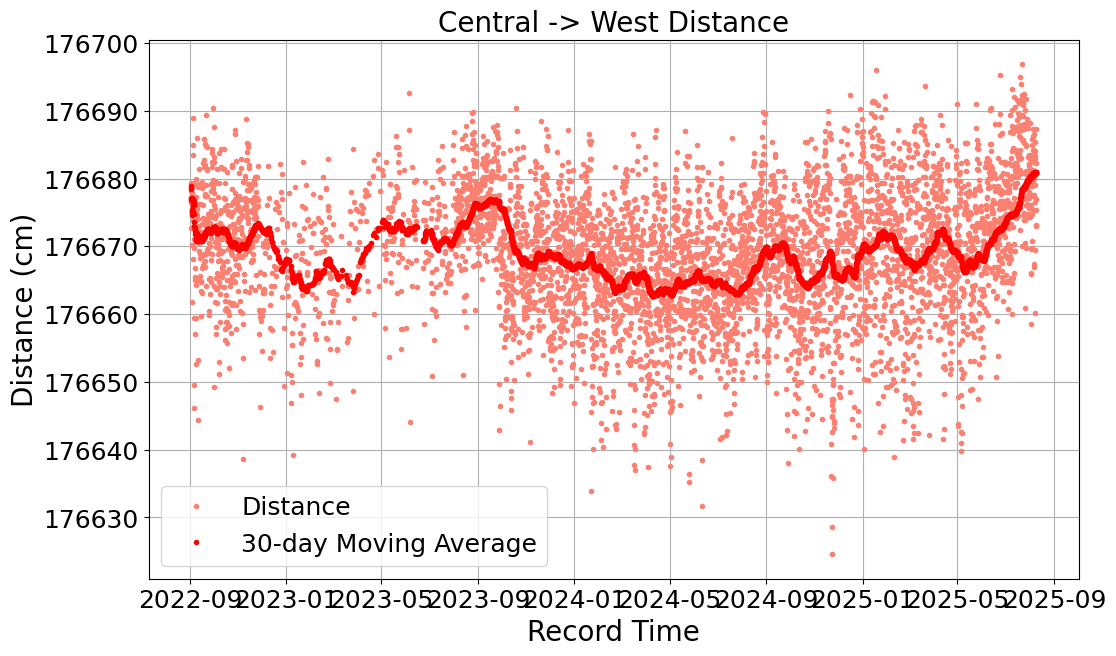

In [225]:

import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams.update({'font.size': 16})
# Ensure 'Record Time' is in datetime format
R2504_2503['Record Time'] = pd.to_datetime(R2504_2503['Record Time'])

# Sort by time to ensure proper rolling calculations
R2504_2503 = R2504_2503.sort_values(by='Record Time')

# Set 'Record Time' as the index
R2504_2503 = R2504_2503.set_index('Record Time')

# Compute 30-day rolling mean
R2504_2503['Moving Average'] = (
    R2504_2503['Harmonic Distance (m)']
    .rolling('30D')
    .mean()
) * 100

# Reset index for plotting
R2504_2503 = R2504_2503.reset_index()
plt.figure(figsize=(12, 7))
plt.plot(R2504_2503['Record Time'], R2504_2503['Harmonic Distance (m)']*100, '.', label="Distance", color='salmon')

# Plot moving average
plt.plot(R2504_2503['Record Time'], 
         R2504_2503['Moving Average'],'r.', 
         label="30-day Moving Average")

# Formatting
plt.xlabel("Record Time")
plt.ylabel("Distance (cm)")
plt.legend()
#plt.ylim(176550,176570)
plt.title("Central -> West Distance")
plt.grid(True)
plt.show()


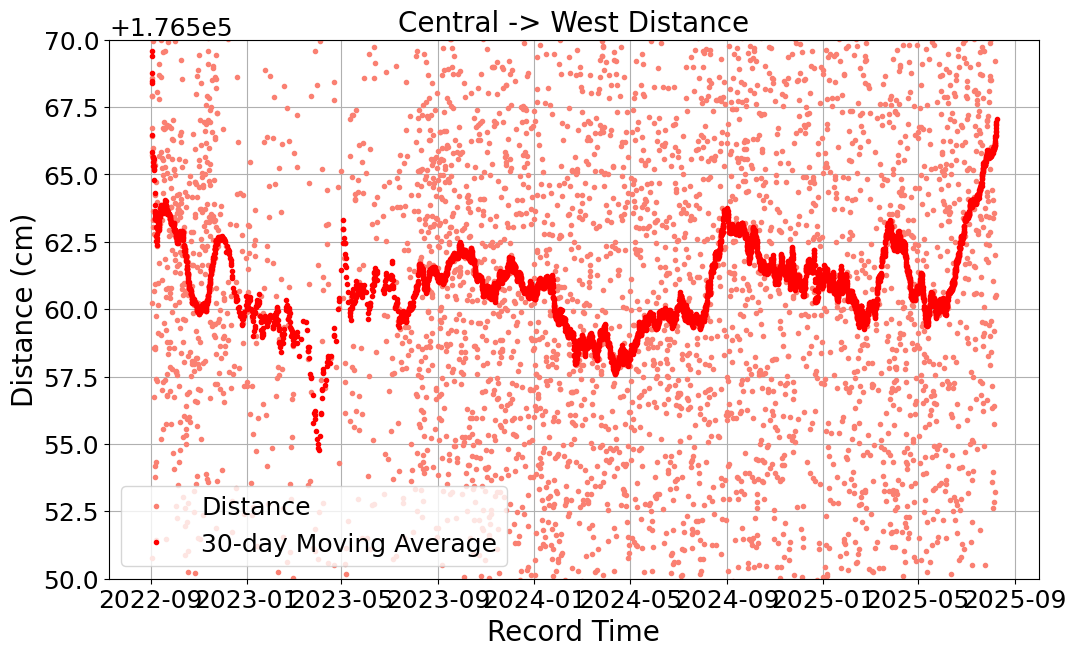

In [226]:
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams.update({'font.size': 16})
# Ensure 'Record Time' is in datetime format
R2504_2503['Record Time'] = pd.to_datetime(R2504_2503['Record Time'])

# Sort by time to ensure proper rolling calculations
R2504_2503 = R2504_2503.sort_values(by='Record Time')

# Set 'Record Time' as the index
R2504_2503 = R2504_2503.set_index('Record Time')

# Compute 30-day rolling mean
R2504_2503['Moving Average'] = (
    R2504_2503['Calculated Distance (m)']
    .rolling('30D')
    .mean()
) * 100

# Reset index for plotting
R2504_2503 = R2504_2503.reset_index()
plt.figure(figsize=(12, 7))
plt.plot(R2504_2503['Record Time'], R2504_2503['Calculated Distance (m)']*100, '.', label="Distance", color='salmon')

# Plot moving average
plt.plot(R2504_2503['Record Time'], 
         R2504_2503['Moving Average'],'r.', 
         label="30-day Moving Average")

# Formatting
plt.xlabel("Record Time")
plt.ylabel("Distance (cm)")
plt.legend()
plt.ylim(176550,176570)
plt.title("Central -> West Distance")
plt.grid(True)
plt.show()


In [227]:
import pandas as pd

# Ensure 'Record Time' is in datetime format
R2504_2503['Record Time'] = pd.to_datetime(R2504_2503['Record Time'])

# Sort by time to ensure proper rolling calculations
R2504_2503 = R2504_2503.sort_values(by='Record Time')

# Set 'Record Time' as the index
R2504_2503 = R2504_2503.set_index('Record Time')

# Compute 30-day rolling mean
R2504_2503['Moving Average'] = (
    R2504_2503['Calculated Distance (m)']
    .rolling('30D')
    .mean()
) * 100

# Reset index
R2504_2503 = R2504_2503.reset_index()

# Create DataFrame with the scatter plot data
scatter_data = pd.DataFrame({
    'Record Time': R2504_2503['Record Time'],
    'Distance (cm)': R2504_2503['Calculated Distance (m)'] * 100,
    'Moving Average (cm)': R2504_2503['Moving Average']
})

# Save to CSV
scatter_data.to_csv('CW_distance.csv', index=False)
print("Data saved to 'CW_distance.csv'")


Data saved to 'CW_distance.csv'


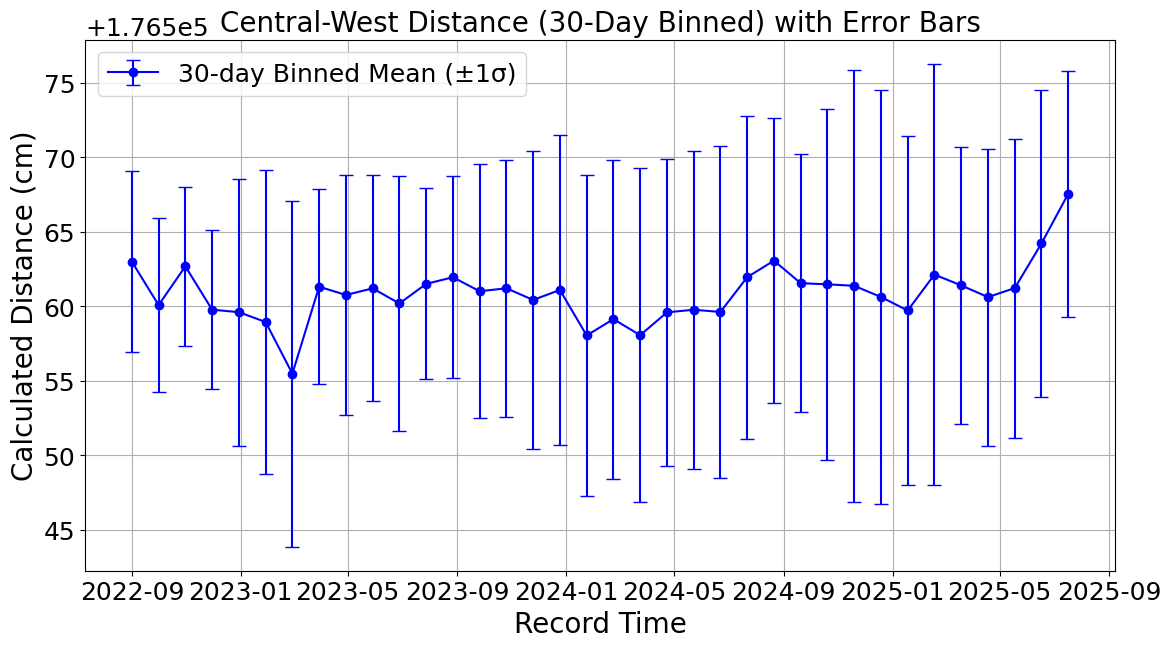

In [228]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'Record Time' is in datetime format
R2504_2503['Record Time'] = pd.to_datetime(R2504_2503['Record Time'])

# Remove any NaN values in 'Calculated Distance (m)'
R2504_2503.dropna(subset=['Calculated Distance (m)'], inplace=True)

# Group data into 30-day bins and calculate mean and standard deviation
binned_data = R2504_2503.resample('30D', on='Record Time').agg({
    'Calculated Distance (m)': ['mean', 'std']
})

# Rename columns for clarity
binned_data.columns = ['Mean Distance', 'Std Dev']

# Convert index (which is now the start of each 30-day bin) to a column for plotting
binned_data = binned_data.reset_index()

# Convert mean values to cm to match original scaling
binned_data['Mean Distance'] *= 100
binned_data['Std Dev'] *= 100

# Plot the binned mean values with error bars (std dev)
plt.figure(figsize=(12, 7))
plt.errorbar(
    binned_data['Record Time'], 
    binned_data['Mean Distance'], 
    yerr=binned_data['Std Dev'], 
    fmt='o-', color='blue', label="30-day Binned Mean (±1σ)", capsize=5
)

plt.title("Central-West Distance (30-Day Binned) with Error Bars")
plt.xlabel("Record Time")
plt.ylabel("Calculated Distance (cm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.rcParams.update({'font.size': 14})
plt.show()


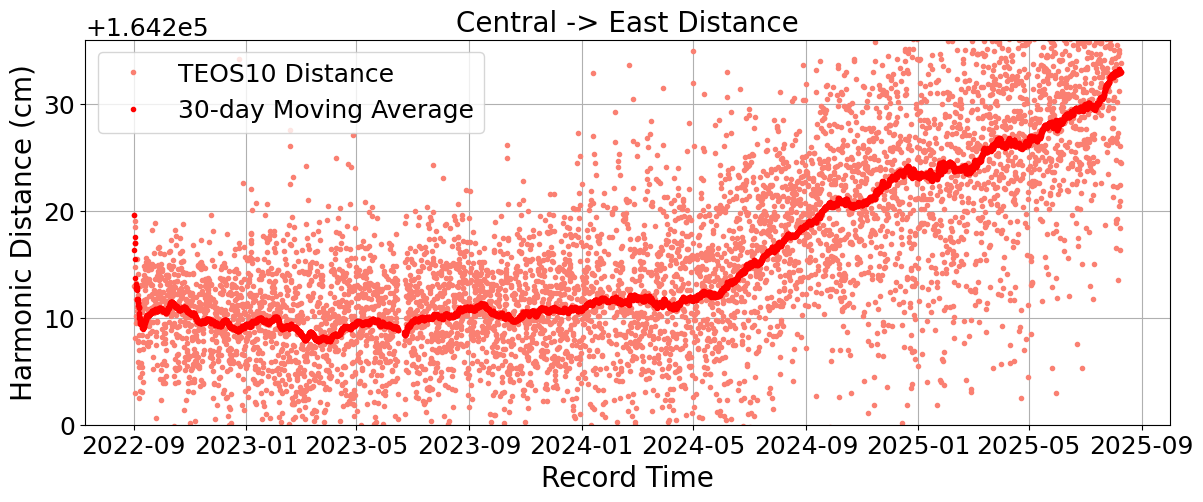

In [229]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'Record Time' is in datetime format
R2504_2502['Record Time'] = pd.to_datetime(R2504_2502['Record Time'])

# Sort by time to ensure proper rolling calculations
R2504_2502 = R2504_2502.sort_values(by='Record Time')

# Set 'Record Time' as the index
R2504_2502 = R2504_2502.set_index('Record Time')

# Compute 30-day rolling mean
R2504_2502['Moving Average'] = (
    R2504_2502['Calculated Distance (m)']
    .rolling('30D')
    .mean()
) * 100

# Reset index for plotting
R2504_2502 = R2504_2502.reset_index()
plt.figure(figsize=(14, 5))
plt.plot(R2504_2502['Record Time'], R2504_2502['Calculated Distance (m)']*100, '.', label="TEOS10 Distance", color='salmon')

# Plot moving average
plt.plot(R2504_2502['Record Time'], 
         R2504_2502['Moving Average'],'r.', 
         label="30-day Moving Average")

# Formatting
plt.xlabel("Record Time")
plt.ylabel("Harmonic Distance (cm)")
plt.legend()
plt.ylim(164200,164236)
plt.title("Central -> East Distance")
plt.grid(True)
plt.show()


In [230]:
import pandas as pd

# Ensure 'Record Time' is in datetime format
R2504_2502['Record Time'] = pd.to_datetime(R2504_2502['Record Time'])

# Sort by time to ensure proper rolling calculations
R2504_2502 = R2504_2502.sort_values(by='Record Time')

# Set 'Record Time' as the index
R2504_2502 = R2504_2502.set_index('Record Time')

# Compute 30-day rolling mean
R2504_2502['Moving Average'] = (
    R2504_2502['Calculated Distance (m)']
    .rolling('30D')
    .mean()
) * 100

# Reset index
R2504_2502 = R2504_2502.reset_index()

# Create DataFrame with the scatter plot data
scatter_data = pd.DataFrame({
    'Record Time': R2504_2502['Record Time'],
    'Distance (cm)': R2504_2502['Calculated Distance (m)'] * 100,
    'Moving Average (cm)': R2504_2502['Moving Average']
})

# Save to CSV
scatter_data.to_csv('CE_distance.csv', index=False)
print("Data saved to 'CE_distance.csv'")

Data saved to 'CE_distance.csv'


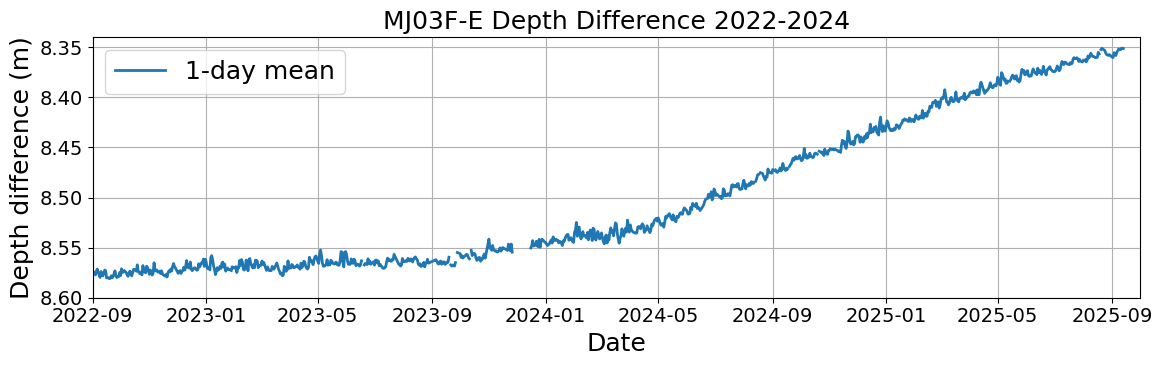

In [231]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

# ====================================================================
# 1) LOAD RAW CP AND EP DATA
# ====================================================================
# Load CP (central) data
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03F*.Data")
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)
cp = pd.concat(df_list, ignore_index=True).sort_values('time')
cp['time'] = pd.to_datetime(cp['time'])

# Load EP (edge) data
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03E*.Data")
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)
ep = pd.concat(df_list, ignore_index=True).sort_values('time')
ep['time'] = pd.to_datetime(ep['time'])

# ====================================================================
# 2) ALIGN AND COMPUTE DIFFERENCES
# ====================================================================
cp_ = cp.copy()
ep_ = ep.copy()

cp_["time"] = pd.to_datetime(cp_["time"], errors="coerce")
ep_["time"] = pd.to_datetime(ep_["time"], errors="coerce")

# Strip timezone
for df in (cp_, ep_):
    try:
        df["time"] = df["time"].dt.tz_convert(None)
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None)
        except Exception:
            pass

# Ensure numeric
for col in ["rawpsi", "depth"]:
    cp_[col] = pd.to_numeric(cp_[col], errors="coerce")
    ep_[col] = pd.to_numeric(ep_[col], errors="coerce")

cp_ = cp_.dropna(subset=["time", "rawpsi", "depth"])
ep_ = ep_.dropna(subset=["time", "rawpsi", "depth"])

# Merge on time
diff_df = pd.merge(
    cp_[["time", "rawpsi", "depth"]],
    ep_[["time", "rawpsi", "depth"]],
    on="time",
    how="inner",
    suffixes=("_cp", "_ep"),
)

diff_df["depth_cp_minus_ep"] = diff_df["depth_cp"] - diff_df["depth_ep"]

# ====================================================================
# 3) DAILY RESAMPLING
# ====================================================================
daily_df = (
    diff_df.set_index("time")[["depth_cp_minus_ep"]]
           .resample("1D")
           .mean()
           .reset_index()
           .rename(columns={"depth_cp_minus_ep": "depth_m"})
)

df_1day = daily_df

# ====================================================================
# 4) OUTLIER REMOVAL (HAMPEL)
# ====================================================================
def hampel_outliers(s: pd.Series, window: int = 9, n_sigmas: float = 4.5) -> pd.Series:
    """Return boolean mask of outliers using rolling median + MAD."""
    med = s.rolling(window, center=True, min_periods=1).median()
    mad = (s - med).abs().rolling(window, center=True, min_periods=1).median()
    sigma = 1.4826 * mad
    return (s - med).abs() > n_sigmas * sigma

df = df_1day.copy()
df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
df = df.dropna(subset=["time", "depth_m"]).sort_values("time").set_index("time")
mask = hampel_outliers(df["depth_m"], window=9, n_sigmas=4.5)
df["depth_m_no_out"] = df["depth_m"].where(~mask)
df_1day = df.reset_index()

# ====================================================================
# 5) PLOT
# ====================================================================
plt.figure(figsize=(12, 4))
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 18,
})
plt.plot(df_1day["time"], df_1day["depth_m_no_out"],
         label="1-day mean", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Date")
plt.ylabel("Depth difference (m)")
plt.title("MJ03F-E Depth Difference 2022-2024")
plt.xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
         pd.Timestamp(2025, 10, 1, tz="UTC"))
plt.ylim(8.6, 8.34)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [232]:
import pandas as pd

# --- same limits as your figure ---
x0 = pd.Timestamp(2022, 9, 1, tz="UTC")
x1 = pd.Timestamp(2025, 10, 1, tz="UTC")
ymin, ymax = 8.6, 8.34  # note: your plot uses inverted y, but the data values are the same

# --- build an "export dataframe" from the plotted series ---
export_df = df_1day[["time", "depth_m_no_out"]].copy()
export_df["time"] = pd.to_datetime(export_df["time"], utc=True, errors="coerce")

# apply the same x/y window you used in the plot (optional but usually what you want)
mask = (
    export_df["time"].between(x0, x1, inclusive="both") &
    export_df["depth_m_no_out"].between(min(ymin, ymax), max(ymin, ymax), inclusive="both")
)
export_df = export_df.loc[mask].dropna(subset=["time", "depth_m_no_out"]).sort_values("time")

# make the CSV nice: ISO timestamps, simple column names
out = export_df.rename(columns={"depth_m_no_out": "depth_difference_m"})
out["time"] = out["time"].dt.strftime("%Y-%m-%dT%H:%M:%SZ")



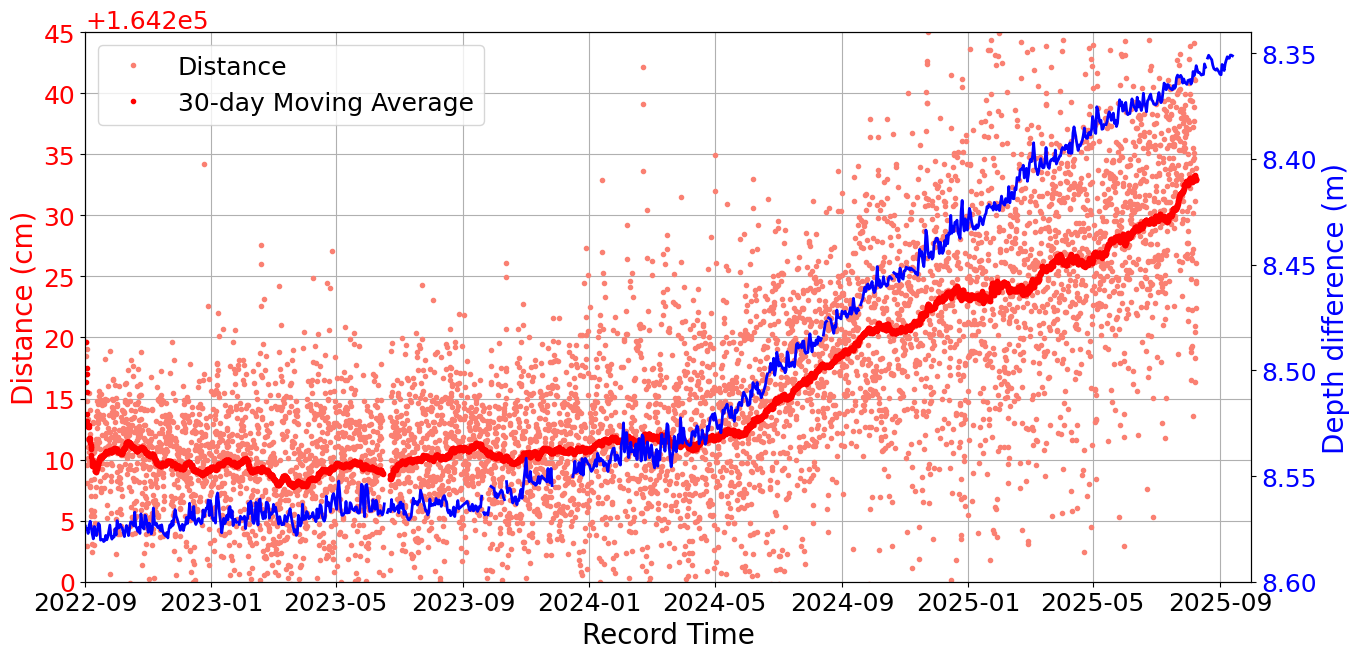

In [233]:
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})

fig, ax1 = plt.subplots(figsize=(14, 7))

# Left axis: Harmonic Distance
ax1.plot(R2504_2502['Record Time'], R2504_2502['Calculated Distance (m)']*100, 
         '.', label="Distance", color='salmon')
ax1.plot(R2504_2502['Record Time'], R2504_2502['Moving Average'],
         'r.', label="30-day Moving Average")
ax1.set_xlabel("Record Time")
ax1.set_ylabel("Distance (cm)", color='red')
ax1.set_ylim(164200, 164245)
ax1.tick_params(axis='y', labelcolor='red')
ax1.grid(True)
ax1.legend(loc='upper left')

# Right axis: Depth Difference
ax2 = ax1.twinx()
ax2.plot(df_1day["time"], df_1day["depth_m_no_out"],
         label="Depth Difference", linewidth=2, color='blue')
ax2.set_ylabel("Depth difference (m)", color='blue')
ax2.set_ylim(8.34,8.6)
ax2.invert_yaxis()
ax2.tick_params(axis='y', labelcolor='blue')
#ax2.legend(loc='upper right')

# Set common x-axis limits
ax1.set_xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
             pd.Timestamp(2025, 10, 1, tz="UTC"))

#plt.title("Central -> East Distance and Depth Difference (F-E)")
plt.tight_layout()
plt.show()

   lag_samples  lag_hours  lag_days  n_pairs  rms_diff_cm  sigma_1sample_cm
0            0          0  0.000000     6289     0.000000          0.000000
1            1          4  0.166667     6135     7.455619          5.271919
2            2          8  0.333333     6067     9.090669          6.428074
3            3         12  0.500000     6005     8.656215          6.120868
4            4         16  0.666667     5951     9.774145          6.911364
5            5         20  0.833333     5894    10.198175          7.211199
6            6         24  1.000000     5841     9.130123          6.455972
7            7         28  1.166667     5792     9.587397          6.779314
8            8         32  1.333333     5741    10.202898          7.214539
9            9         36  1.500000     5696     9.436103          6.672332


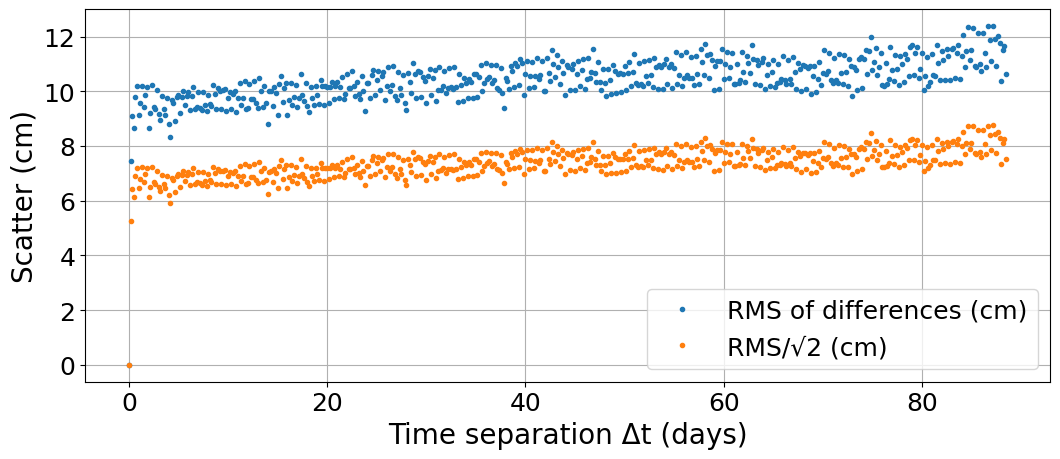

In [234]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def scatter_vs_lag_4h_shift(
    df,
    time_col="Record Time",
    dist_m_col="Calculated Distance (m)",
    max_lag_days=60,
    min_pairs=200,
    agg="median",
    consecutive=False
):
    """
    For 4-hour data:
      - resample to 4H grid
      - for each lag k (k*4 hours), compute diff = x(t+k)-x(t)
      - RMS(diff) = scatter of 2-point change
      - sigma_1sample = RMS/sqrt(2) (if interpreting as per-sample noise at small lags)

    consecutive=True:
      Only keep pairs where *every* 4H sample between t and t+k exists (no gaps inside the window).
    """
    # time + distance in cm
    t = pd.to_datetime(df[time_col], utc=True, errors="coerce")
    x_cm = pd.to_numeric(df[dist_m_col], errors="coerce") * 100.0
    s = pd.Series(x_cm.values, index=t).dropna().sort_index()

    # regularize to 4H
    if agg == "median":
        x4 = s.resample("4H").median()
    elif agg == "mean":
        x4 = s.resample("4H").mean()
    else:
        raise ValueError("agg must be 'median' or 'mean'")

    samples_per_day = 6
    max_k = int(max_lag_days * samples_per_day)

    rows = []
    for k in range(0, max_k + 1):
        a = x4
        b = x4.shift(-k)

        valid = a.notna() & b.notna()

        if consecutive and k > 0:
            # require no NaNs anywhere in the window length k+1
            # (rolling count equals window length means fully populated)
            full = x4.notna().rolling(window=k+1).sum()
            # align with the start time of the window
            valid = valid & (full == (k+1))

        diffs = (b[valid] - a[valid]).values
        n = diffs.size

        if n < min_pairs:
            rows.append([k, 4*k, k/samples_per_day, n, np.nan, np.nan])
            continue

        rms = float(np.sqrt(np.mean(diffs**2)))
        sigma = float(rms / np.sqrt(2.0))

        rows.append([k, 4*k, k/samples_per_day, n, rms, sigma])

    res = pd.DataFrame(
        rows,
        columns=["lag_samples", "lag_hours", "lag_days", "n_pairs", "rms_diff_cm", "sigma_1sample_cm"]
    )
    return res, x4


# ---- Example run ----
res, x4 = scatter_vs_lag_4h_shift(
    R2504_2502,
    max_lag_days=90,
    min_pairs=500,
    consecutive=True   # <- try True and False and see if it changes much
)

print(res.head(10))

# ---- Plot ----
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(res["lag_days"], res["rms_diff_cm"], ".", label="RMS of differences (cm)")
ax.plot(res["lag_days"], res["sigma_1sample_cm"], ".", label="RMS/√2 (cm)")
ax.set_xlabel("Time separation Δt (days)")
ax.set_ylabel("Scatter (cm)")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()


In [235]:
t = pd.to_datetime(R2504_2502["Record Time"], utc=True, errors="coerce")
dt_hours = pd.Series(t).sort_values().diff().dt.total_seconds()/3600
print("Median Δt (hours):", float(dt_hours.median()))
print("90% Δt (hours):", float(dt_hours.quantile(0.90)))
print("99% Δt (hours):", float(dt_hours.quantile(0.99)))


Median Δt (hours): 4.0
90% Δt (hours): 4.0
99% Δt (hours): 8.0


In [236]:
import numpy as np
import pandas as pd

# --- prep ---
df = R2504_2502[['Record Time','Calculated Distance (m)']].dropna().copy()
df = df.rename(columns={'Calculated Distance (m)':'distance_m'})
df['Record Time'] = pd.to_datetime(df['Record Time'])
df = df.sort_values('Record Time').set_index('Record Time')

# 30-day windows: mean and std within each window
binned = (
    df.groupby(pd.Grouper(freq='30D'))
      .agg(distance_mean_m=('distance_m','mean'),
           distance_std_m =('distance_m','std'),
           count          =('distance_m','size'))
      .reset_index()
)

# keep reasonable windows
binned = binned[binned['count'] >= 10].copy()

# --- Precision metrics ---
# Absolute precision in mm (optional, for reference)
binned['precision_abs_mm'] = binned['distance_std_m'] * 1000.0

# Relative precision in ppm (optional) and cm/km (requested)
binned['precision_ppm']      = 1e6 * (binned['distance_std_m'] / binned['distance_mean_m'])
binned['precision_cm_per_km'] = binned['precision_ppm'] / 10.0     # == 1e5 * std/mean

# Summaries you can report
median_cm_per_km = binned['precision_cm_per_km'].median()
q25 = binned['precision_cm_per_km'].quantile(0.25)
q75 = binned['precision_cm_per_km'].quantile(0.75)

print(f"30-day precision (median): {median_cm_per_km:.2f} cm/km")
print(f"IQR: {q25:.2f}–{q75:.2f} cm/km over {len(binned)} windows")


30-day precision (median): 3.69 cm/km
IQR: 2.92–4.56 cm/km over 36 windows


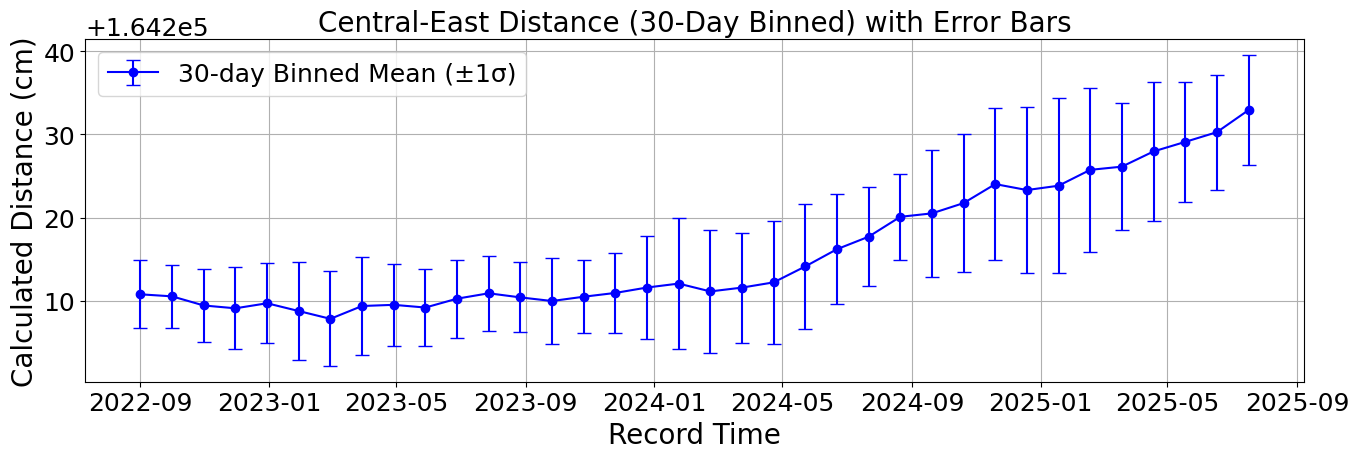

In [237]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'Record Time' is in datetime format
R2504_2502['Record Time'] = pd.to_datetime(R2504_2502['Record Time'])

# Remove any NaN values in 'Calculated Distance (m)'
R2504_2502.dropna(subset=['Calculated Distance (m)'], inplace=True)

# Group data into 30-day bins and calculate mean and standard deviation
binned_data = R2504_2502.resample('30D', on='Record Time').agg({
    'Calculated Distance (m)': ['mean', 'std']
})

# Rename columns for clarity
binned_data.columns = ['Mean Distance', 'Std Dev']

# Convert index (which is now the start of each 30-day bin) to a column for plotting
binned_data = binned_data.reset_index()

# Convert mean values to cm to match original scaling
binned_data['Mean Distance'] *= 100
binned_data['Std Dev'] *= 100

# Plot the binned mean values with error bars (std dev)
plt.figure(figsize=(14, 5))
plt.errorbar(
    binned_data['Record Time'], 
    binned_data['Mean Distance'], 
    yerr=binned_data['Std Dev'], 
    fmt='o-', color='blue', label="30-day Binned Mean (±1σ)", capsize=5
)

plt.title("Central-East Distance (30-Day Binned) with Error Bars")
plt.xlabel("Record Time")
plt.ylabel("Calculated Distance (cm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.rcParams.update({'font.size': 14})
plt.show()


In [238]:
R2504_2502 = R2504_2502.dropna(axis=1, how='all')
R2504_2502

,Record Time,BSL,Retrieval Time,Node Ref,UID,RangeNode Ref,RangeAddress,Range(ms),TAT(ms),Interpolated Sound Speed,Calculated Distance (m),Interpolated Harmonic Velocity,Harmonic Distance (m),Moving Average
0,2022-09-01 19:30:00,BSL,7/24/23 1:47,North,00687A,East,2502,2373.113,160.0,1484.060266,1642.196534,1484.019206,1642.151099,164219.653354
1,2022-09-01 23:30:00,BSL,7/24/23 1:47,North,00687A,East,2502,2373.023,160.0,1484.060266,1642.129751,1484.044653,1642.112475,164216.314218
2,2022-09-02 03:30:00,BSL,7/24/23 1:47,North,00687A,East,2502,2373.097,160.0,1484.060266,1642.184661,1484.040356,1642.162630,164217.031514
3,2022-09-02 11:30:00,BSL,7/24/23 1:47,North,00687A,East,2502,2373.105,160.0,1484.060266,1642.190597,1484.069161,1642.200440,164217.538568
4,2022-09-02 15:30:00,BSL,7/24/23 1:47,North,00687A,East,2502,2373.112,160.0,1484.016736,1642.147623,1484.036346,1642.169323,164216.983314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6286,2025-08-08 11:30:00,BSL,2025/08/09 07:56:36,South,00687A,East,2502,2373.183,160.0,1484.057920,1642.245880,1484.168358,1642.368089,164232.935507
6287,2025-08-08 15:30:00,BSL,2025/08/09 07:56:52,South,00687A,East,2502,2373.154,160.0,1484.057920,1642.224361,1484.207248,1642.389603,164232.872579
6288,2025-08-08 19:30:00,BSL,2025/08/09 07:56:52,South,00687A,East,2502,2373.203,160.0,1484.057920,1642.260720,1484.155664,1642.368884,164232.951934
6289,2025-08-08 23:30:00,BSL,2025/08/09 07:56:52,South,00687A,East,2502,2373.181,160.0,1484.057920,1642.244395,1484.072614,1642.260655,164232.968360


In [239]:
R2504_2503 = R2504_2503.dropna(axis=1, how='all')
R2504_2503

,Record Time,BSL,Retrieval Time,Node Ref,UID,RangeNode Ref,RangeAddress,Range(ms),TAT(ms),Interpolated Sound Speed,Calculated Distance (m),Interpolated Harmonic Velocity,Harmonic Distance (m),Moving Average
0,2022-09-01 19:30:00,BSL,7/24/23 1:47,North,00687A,West,2503,2620.339,240.0,1483.598301,1765.733448,1484.4812,1766.784248,176573.344799
1,2022-09-01 23:30:00,BSL,7/24/23 1:47,North,00687A,West,2503,2620.303,240.0,1483.598301,1765.706743,1484.5114,1766.793469,176572.009560
2,2022-09-02 07:30:00,BSL,7/24/23 1:47,North,00687A,West,2503,2620.246,240.0,1483.598301,1765.664461,1484.4917,1766.727715,176570.155062
3,2022-09-02 11:30:00,BSL,7/24/23 1:47,North,00687A,West,2503,2620.266,240.0,1483.598301,1765.679297,1484.5242,1766.781240,176569.598713
4,2022-09-02 15:30:00,BSL,7/24/23 1:47,North,00687A,West,2503,2620.259,240.0,1483.608055,1765.685712,1484.5140,1766.763905,176569.393213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5165,2025-08-08 11:30:00,BSL,2025/08/09 07:56:36,South,00687A,West,2503,2620.062,240.0,1483.769879,1765.732153,1484.6279,1766.753224,176566.715942
5166,2025-08-08 15:30:00,BSL,2025/08/09 07:56:52,South,00687A,West,2503,2620.206,240.0,1483.769879,1765.838984,1484.5973,1766.823701,176566.819987
5167,2025-08-08 19:30:00,BSL,2025/08/09 07:56:52,South,00687A,West,2503,2620.216,240.0,1483.769879,1765.846403,1484.5135,1766.731392,176566.861470
5168,2025-08-08 23:30:00,BSL,2025/08/09 07:56:52,South,00687A,West,2503,2620.254,240.0,1483.769879,1765.874595,1484.5227,1766.770547,176566.939732


## 2503 to central and east

In [240]:
# Extract DataFrames based on the 'RangeAddress' column values
bsl_df = df_dict['2503']['BSL']
bsl_df['RangeAddress'] = bsl_df['RangeAddress'].astype(int).astype(str)
bsl_df['Range(ms)'] = pd.to_numeric(bsl_df['Range(ms)'], errors='coerce')
bsl_df['TAT(ms)'] = pd.to_numeric(bsl_df['TAT(ms)'], errors='coerce')
bsl_2502_df = bsl_df[bsl_df['RangeAddress'] == '2502'].copy()
bsl_2504_df = bsl_df[bsl_df['RangeAddress'] == '2504'].copy()

# Calculate the IQR for the 'Range(ms)' column in bsl_2502_df
Q1 = bsl_2502_df['Range(ms)'].quantile(0.25)
Q3 = bsl_2502_df['Range(ms)'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
filtered_bsl_2502_df = bsl_2502_df[(bsl_2502_df['Range(ms)'] >= lower_bound) & (bsl_2502_df['Range(ms)'] <= upper_bound)]
outside_values_df1 = bsl_2502_df[(bsl_2502_df['Range(ms)'] < lower_bound) | (bsl_2502_df['Range(ms)'] > upper_bound)]

# Convert the 'Range(ms)' column to numeric for plotting
bsl_2502_df['Range(ms)'] = pd.to_numeric(bsl_2502_df['Range(ms)'], errors='coerce')

# Calculate the IQR for the 'Range(ms)' column in bsl_2502_df
Q1 = bsl_2504_df['Range(ms)'].quantile(0.25)
Q3 = bsl_2504_df['Range(ms)'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


# Filter out data points with 'Range(ms)' values using IQR
filtered_bsl_2504_df = bsl_2504_df[(bsl_2504_df['Range(ms)'] >= lower_bound) & (bsl_2504_df['Range(ms)'] <= upper_bound)]
outside_values_df2 = bsl_2504_df[(bsl_2504_df['Range(ms)'] < lower_bound) | (bsl_2504_df['Range(ms)'] > upper_bound)]


# Convert the 'Range(ms)' column to numeric for plotting
bsl_2504_df['Range(ms)'] = pd.to_numeric(bsl_2504_df['Range(ms)'], errors='coerce')

# Creating explicit copies of the DataFrames to avoid the warning
filtered_bsl_2502_copy = filtered_bsl_2502_df.copy()
filtered_bsl_2504_copy = filtered_bsl_2504_df.copy()

# Create explicit copies to avoid the SettingWithCopyWarning
filtered_bsl_2502_copy = filtered_bsl_2502_df.copy()

ensure_datetime(filtered_bsl_2502_copy, 'Record Time')
ensure_datetime(harmonic_df_dict['2502_2503'], 'Record Time')


#-------------------------------------------------------------------------------------
# Interpolate sound speed values onto the filtered_bsl_2502_copy timestamps
filtered_bsl_2502_copy['Interpolated Sound Speed'] = np.interp(
    filtered_bsl_2502_copy['Record Time'].astype(np.int64),
    harmonic_df_dict['2502_2503']['Record Time'].view(np.int64),
    harmonic_df_dict['2502_2503']['HMean']
)

# Calculate distance using the interpolated sound speeds
filtered_bsl_2502_copy['Calculated Distance (m)'] = filtered_bsl_2502_copy['Interpolated Sound Speed'] * ((filtered_bsl_2502_copy['Range(ms)']-filtered_bsl_2502_copy['TAT(ms)']) / 2000)  # Dividing by 2000 to convert ms to seconds and account for two-way travel
# Display the top rows of the updated dataframe
filtered_bsl_2502_copy[['Record Time', 'Range(ms)', 'Interpolated Sound Speed', 'Calculated Distance (m)']].head()

##############
filtered_bsl_2502_copy['Interpolated Harmonic Velocity'] = np.interp(
    filtered_bsl_2502_copy['Record Time'].view(np.int64),
    harmonic_mean_dfs['2502_2504']['Record Time'].view(np.int64),
    harmonic_mean_dfs['2502_2504']['Harmonic Mean']
)

# Calculate distance using the interpolated sound speeds
filtered_bsl_2502_copy['Harmonic Distance (m)'] = filtered_bsl_2502_copy['Interpolated Harmonic Velocity'] * ((filtered_bsl_2502_copy['Range(ms)']-filtered_bsl_2502_copy['TAT(ms)']) / 2000)  # Dividing by 2000 to convert ms to seconds and account for two-way travel

filtered_bsl_2502_copy = apply_tilt_correction(
    filtered_bsl_2502_copy, "2502-2503", baseline_perturb
)

R2503_2502 = filtered_bsl_2502_copy


##-------------------------------------------------------------------------------------
ensure_datetime(filtered_bsl_2504_copy, 'Record Time')
ensure_datetime(harmonic_df_dict['2503_2504'], 'Record Time')

# Interpolate sound speed values onto the filtered_bsl_2502_copy timestamps
filtered_bsl_2504_copy['Interpolated Sound Speed'] = np.interp(
    filtered_bsl_2504_copy['Record Time'].astype(np.int64),
    harmonic_df_dict['2503_2504']['Record Time'].view(np.int64),
    harmonic_df_dict['2503_2504']['HMean']
)

# Calculate distance using the interpolated sound speeds
filtered_bsl_2504_copy['Calculated Distance (m)'] = filtered_bsl_2504_copy['Interpolated Sound Speed'] * ((filtered_bsl_2504_copy['Range(ms)']-filtered_bsl_2504_copy['TAT(ms)']) / 2000)  # Dividing by 2000 to convert ms to seconds and account for two-way travel
# Display the top rows of the updated dataframe
filtered_bsl_2504_copy[['Record Time', 'Range(ms)', 'Interpolated Sound Speed', 'Calculated Distance (m)']].head()

##----------------------------------------------------------------------------------------------------------------
filtered_bsl_2504_copy['Interpolated Harmonic Velocity'] = np.interp(
    filtered_bsl_2504_copy['Record Time'].view(np.int64),
    harmonic_mean_dfs['2503_2504']['Record Time'].view(np.int64),
    harmonic_mean_dfs['2503_2504']['Harmonic Mean']
)

# Calculate distance using the interpolated sound speeds
filtered_bsl_2504_copy['Harmonic Distance (m)'] = filtered_bsl_2504_copy['Interpolated Harmonic Velocity'] * ((filtered_bsl_2504_copy['Range(ms)']-filtered_bsl_2504_copy['TAT(ms)']) / 2000)  # Dividing by 2000 to convert ms to seconds and account for two-way travel
##############

filtered_bsl_2504_copy = apply_tilt_correction(
    filtered_bsl_2504_copy, "2504-2503", baseline_perturb
)

R2503_2504 = filtered_bsl_2504_copy



/tmp/ipykernel_1893829/1507283314.py:57: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column_name] = pd.to_datetime(df[column_name])
/tmp/ipykernel_1893829/1507283314.py:57: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column_name] = pd.to_datetime(df[column_name])


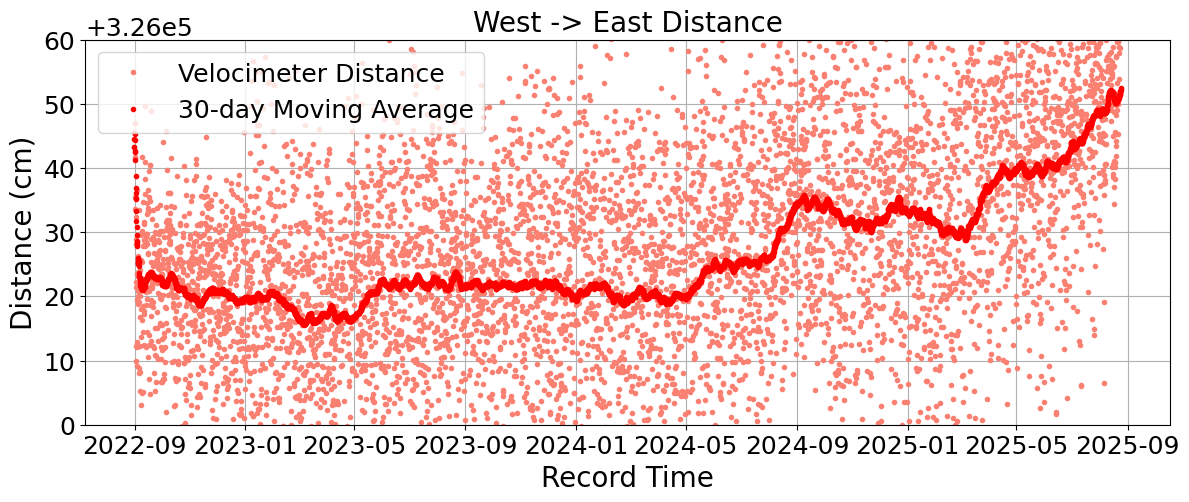

In [241]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'Record Time' is in datetime format
R2503_2502['Record Time'] = pd.to_datetime(R2503_2502['Record Time'])

# Sort by time to ensure proper rolling calculations
R2503_2502 = R2503_2502.sort_values(by='Record Time')

# Set 'Record Time' as the index
R2503_2502 = R2503_2502.set_index('Record Time')

# Compute 30-day rolling mean
R2503_2502['Moving Average'] = (
    R2503_2502['Calculated Distance (m)']
    .rolling('30D')
    .mean()
) * 100

# Reset index for plotting
R2503_2502 = R2503_2502.reset_index()
plt.figure(figsize=(14, 5))
plt.plot(R2503_2502['Record Time'], R2503_2502['Calculated Distance (m)']*100, '.', label="Velocimeter Distance", color='salmon')

# Plot moving average
plt.plot(R2503_2502['Record Time'], R2503_2502['Moving Average'],'r.',label="30-day Moving Average")


# Formatting
plt.xlabel("Record Time")
plt.ylabel("Distance (cm)")
plt.legend()
plt.ylim(326000,326060)
plt.title("West -> East Distance")
plt.grid(True)
plt.show()


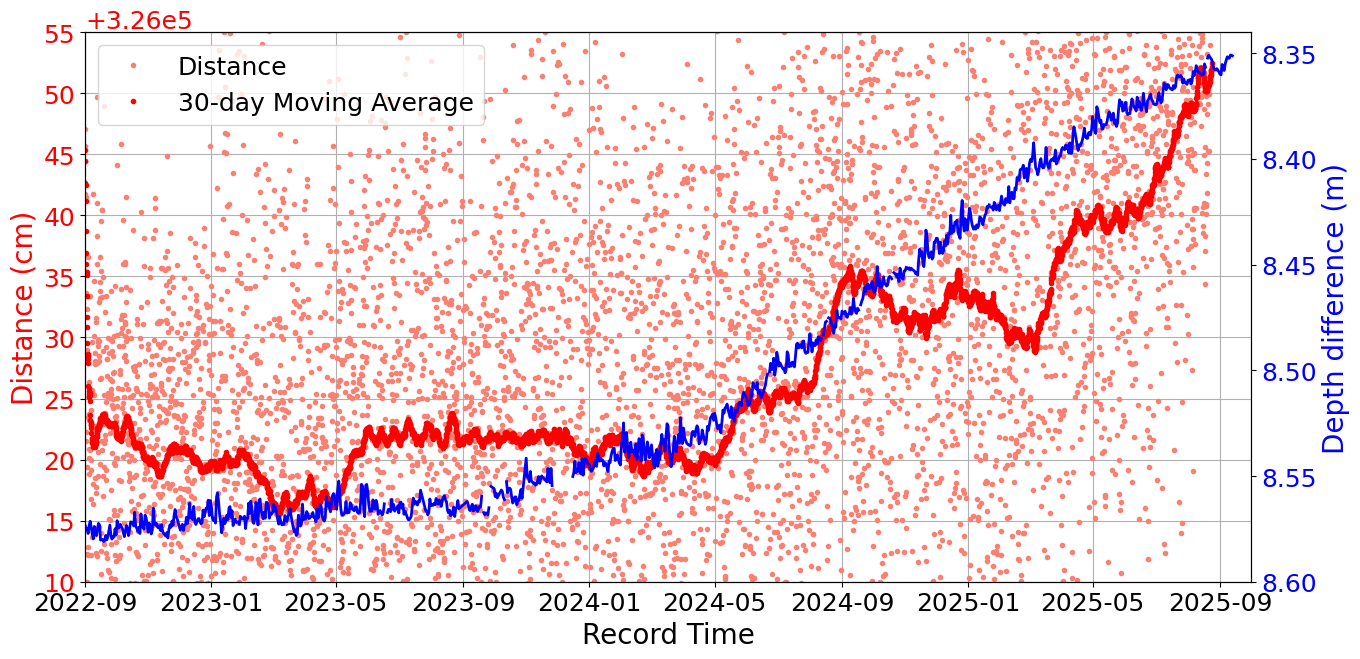

In [242]:
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})

fig, ax1 = plt.subplots(figsize=(14, 7))

# Left axis: Harmonic Distance
ax1.plot(R2503_2502['Record Time'], R2503_2502['Calculated Distance (m)']*100, '.', label="Distance", color='salmon')
ax1.plot(R2503_2502['Record Time'], R2503_2502['Moving Average'],'r.',label="30-day Moving Average")

ax1.set_xlabel("Record Time")
ax1.set_ylabel("Distance (cm)", color='red')
ax1.set_ylim(326010,326055)
ax1.tick_params(axis='y', labelcolor='red')
ax1.grid(True)
ax1.legend(loc='upper left')

# Right axis: Depth Difference
ax2 = ax1.twinx()
ax2.plot(df_1day["time"], df_1day["depth_m_no_out"],
         label="Depth Difference", linewidth=2, color='blue')
ax2.set_ylabel("Depth difference (m)", color='blue')
ax2.set_ylim(8.34,8.6)
ax2.invert_yaxis()
ax2.tick_params(axis='y', labelcolor='blue')
#ax2.legend(loc='upper right')

# Set common x-axis limits
ax1.set_xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
             pd.Timestamp(2025, 10, 1, tz="UTC"))

#plt.title("Central -> East Distance and Depth Difference (F-E)")
plt.tight_layout()
plt.show()

In [243]:
import numpy as np
import pandas as pd

def scatter_4h_two_numbers(df, time_col="Record Time", dist_m_col="Calculated Distance (m)"):
    # time + distance in cm
    t = pd.to_datetime(df[time_col], utc=True, errors="coerce")
    x_cm = pd.to_numeric(df[dist_m_col], errors="coerce") * 100.0
    s = pd.Series(x_cm.values, index=t).dropna().sort_index()

    # regularize to 4-hour grid (median in each 4H bin)
    x4 = s.resample("4H").median()

    # 4-hour lag = 1 sample
    diffs = (x4.shift(-1) - x4).dropna()
    rms_diff = float(np.sqrt(np.mean(diffs.values**2)))
    sigma_1 = float(rms_diff / np.sqrt(2.0))

    return {
        "n_pairs": int(diffs.size),
        "rms_pairwise_diff_4h_cm": rms_diff,
        "equiv_1sample_sigma_cm": sigma_1,
    }

out = scatter_4h_two_numbers(R2503_2502)

print(f"R2503-2502 (4h): n={out['n_pairs']}")
print(f"  RMS pairwise difference (Δd, 4h) = {out['rms_pairwise_diff_4h_cm']:.3f} cm")
print(f"  Equivalent 1-sample scatter (1σ) = {out['equiv_1sample_sigma_cm']:.3f} cm  (RMS/√2)")


R2503-2502 (4h): n=6455
  RMS pairwise difference (Δd, 4h) = 20.032 cm
  Equivalent 1-sample scatter (1σ) = 14.165 cm  (RMS/√2)


In [244]:
import pandas as pd

# Ensure 'Record Time' is in datetime format
R2503_2502['Record Time'] = pd.to_datetime(R2503_2502['Record Time'])

# Sort by time to ensure proper rolling calculations
R2503_2502 = R2503_2502.sort_values(by='Record Time')

# Set 'Record Time' as the index
R2503_2502 = R2503_2502.set_index('Record Time')

# Compute 30-day rolling mean
R2503_2502['Moving Average'] = (
    R2503_2502['Calculated Distance (m)']
    .rolling('30D')
    .mean()
) * 100

# Reset index
R2503_2502 = R2503_2502.reset_index()

# Create DataFrame with the scatter plot data
scatter_data = pd.DataFrame({
    'Record Time': R2503_2502['Record Time'],
    'Distance (cm)': R2503_2502['Calculated Distance (m)'] * 100,
    'Moving Average (cm)': R2503_2502['Moving Average']
})

# Save to CSV
scatter_data.to_csv('WE_distance.csv', index=False)
print("Data saved to 'WE_distance.csv'")


Data saved to 'WE_distance.csv'


In [245]:
import numpy as np
import pandas as pd

# --- prep ---
df = R2503_2502[['Record Time','Calculated Distance (m)']].dropna().copy()
df = df.rename(columns={'Calculated Distance (m)':'distance_m'})
df['Record Time'] = pd.to_datetime(df['Record Time'])
df = df.sort_values('Record Time').set_index('Record Time')

# 30-day windows: mean and std within each window
binned = (
    df.groupby(pd.Grouper(freq='30D'))
      .agg(distance_mean_m=('distance_m','mean'),
           distance_std_m =('distance_m','std'),
           count          =('distance_m','size'))
      .reset_index()
)

# keep reasonable windows
binned = binned[binned['count'] >= 10].copy()

# --- Precision metrics ---
# Absolute precision in mm (optional, for reference)
binned['precision_abs_mm'] = binned['distance_std_m'] * 1000.0

# Relative precision in ppm (optional) and cm/km (requested)
binned['precision_ppm']      = 1e6 * (binned['distance_std_m'] / binned['distance_mean_m'])
binned['precision_cm_per_km'] = binned['precision_ppm'] / 10.0     # == 1e5 * std/mean

# Summaries you can report
median_cm_per_km = binned['precision_cm_per_km'].median()
q25 = binned['precision_cm_per_km'].quantile(0.25)
q75 = binned['precision_cm_per_km'].quantile(0.75)

print(f"30-day precision (median): {median_cm_per_km:.2f} cm/km")
print(f"IQR: {q25:.2f}–{q75:.2f} cm/km over {len(binned)} windows")


30-day precision (median): 4.82 cm/km
IQR: 4.09–5.30 cm/km over 37 windows


In [246]:
R2503_2502

,Record Time,BSL,Retrieval Time,Node Ref,UID,RangeNode Ref,RangeAddress,Range(ms),TAT(ms),NaN,...,NaN,NaN,NaN,Interpolated Sound Speed,Calculated Distance (m),Interpolated Harmonic Velocity,Harmonic Distance (m),2502-2503_dL,Distance_tiltcorr(m),Moving Average
0,2022-08-31 16:30:00,BSL,9/3/23 18:22,West,6874,East,2502,4556.569,160.0,NaN,...,NaN,NaN,NaN,1483.171257,3260.432385,1484.005599,3262.266507,NaN,NaN,326043.238505
1,2022-08-31 20:30:00,BSL,9/3/23 18:22,West,6874,East,2502,4556.602,160.0,NaN,...,NaN,NaN,NaN,1483.171257,3260.456857,1484.005599,3262.290993,NaN,NaN,326044.462121
2,2022-09-01 00:30:00,BSL,9/3/23 18:22,West,6874,East,2502,4556.621,160.0,NaN,...,NaN,NaN,NaN,1483.171257,3260.470947,1484.005599,3262.305091,NaN,NaN,326045.339664
3,2022-09-01 04:30:00,BSL,9/3/23 18:22,West,6874,East,2502,4556.549,160.0,NaN,...,NaN,NaN,NaN,1483.171257,3260.417553,1484.005599,3262.251667,NaN,NaN,326044.443581
4,2022-09-01 08:30:00,BSL,9/3/23 18:22,West,6874,East,2502,4556.464,160.0,NaN,...,NaN,NaN,NaN,1483.171257,3260.354519,1484.005599,3262.188596,NaN,NaN,326042.645236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6485,2025-08-23 12:30:00,BSL,2025/08/24 08:42:20,West,6874,East,2502,4556.607,160.0,NaN,...,NaN,NaN,NaN,1483.273557,3260.685452,1484.046517,3262.384653,NaN,NaN,326051.821891
6486,2025-08-23 16:30:00,BSL,2025/08/24 08:42:20,West,6874,East,2502,4556.677,160.0,NaN,...,NaN,NaN,NaN,1483.273557,3260.737366,1484.046517,3262.436594,NaN,NaN,326051.900369
6487,2025-08-23 20:30:00,BSL,2025/08/24 08:42:20,West,6874,East,2502,4556.505,160.0,NaN,...,NaN,NaN,NaN,1483.273557,3260.609805,1484.046517,3262.308966,NaN,NaN,326052.016745
6488,2025-08-24 00:30:00,BSL,2025/08/24 08:42:20,West,6874,East,2502,4556.683,160.0,NaN,...,NaN,NaN,NaN,1483.273557,3260.741816,1484.046517,3262.441047,NaN,NaN,326052.139297


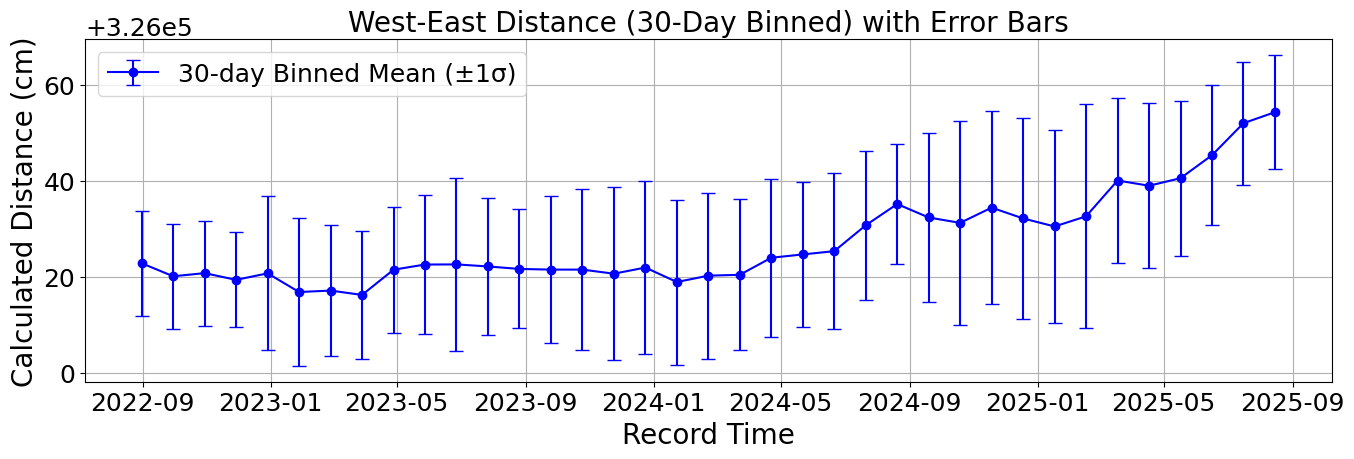

In [247]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'Record Time' is in datetime format
R2503_2502['Record Time'] = pd.to_datetime(R2503_2502['Record Time'])

# Remove any NaN values in 'Calculated Distance (m)'
R2503_2502.dropna(subset=['Calculated Distance (m)'], inplace=True)

# Group data into 30-day bins and calculate mean and standard deviation
binned_data = R2503_2502.resample('30D', on='Record Time').agg({
    'Calculated Distance (m)': ['mean', 'std']
})

# Rename columns for clarity
binned_data.columns = ['Mean Distance', 'Std Dev']

# Convert index (which is now the start of each 30-day bin) to a column for plotting
binned_data = binned_data.reset_index()

# Convert mean values to cm to match original scaling
binned_data['Mean Distance'] *= 100
binned_data['Std Dev'] *= 100

# Plot the binned mean values with error bars (std dev)
plt.figure(figsize=(14, 5))
plt.errorbar(
    binned_data['Record Time'], 
    binned_data['Mean Distance'], 
    yerr=binned_data['Std Dev'], 
    fmt='o-', color='blue', label="30-day Binned Mean (±1σ)", capsize=5
)

plt.title("West-East Distance (30-Day Binned) with Error Bars")
plt.xlabel("Record Time")
plt.ylabel("Calculated Distance (cm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.rcParams.update({'font.size': 14})
plt.show()


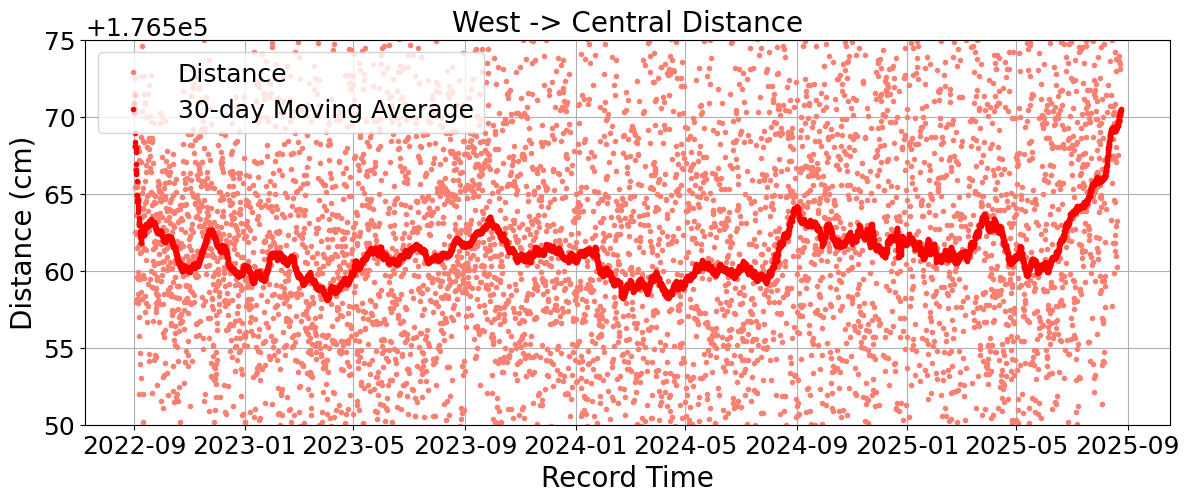

In [248]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'Record Time' is in datetime format
R2503_2504['Record Time'] = pd.to_datetime(R2503_2504['Record Time'])

# Sort by time to ensure proper rolling calculations
R2503_2504 = R2503_2504.sort_values(by='Record Time')

# Set 'Record Time' as the index
R2503_2504 = R2503_2504.set_index('Record Time')

# Compute 30-day rolling mean
R2503_2504['Moving Average'] = (
    R2503_2504['Calculated Distance (m)']
    .rolling('30D')
    .mean()
) * 100

# Reset index for plotting
R2503_2504 = R2503_2504.reset_index()
plt.figure(figsize=(14, 5))
plt.plot(R2503_2504['Record Time'], R2503_2504['Calculated Distance (m)']*100, '.', label="Distance", color='salmon')

# Plot moving average
plt.plot(R2503_2504['Record Time'], 
         R2503_2504['Moving Average'],'r.', 
         label="30-day Moving Average")

# Formatting
plt.xlabel("Record Time")
plt.ylabel("Distance (cm)")
plt.legend()
plt.ylim(176550,176575)
plt.title("West -> Central Distance")
plt.grid(True)
plt.show()


In [249]:
import pandas as pd

# Ensure 'Record Time' is in datetime format
R2503_2504['Record Time'] = pd.to_datetime(R2503_2504['Record Time'])

# Sort by time to ensure proper rolling calculations
R2503_2504 = R2503_2504.sort_values(by='Record Time')

# Set 'Record Time' as the index
R2503_2504 = R2503_2504.set_index('Record Time')

# Compute 30-day rolling mean
R2503_2504['Moving Average'] = (
    R2503_2504['Calculated Distance (m)']
    .rolling('30D')
    .mean()
) * 100

# Reset index
R2503_2504 = R2503_2504.reset_index()

# Create DataFrame with the scatter plot data
scatter_data = pd.DataFrame({
    'Record Time': R2503_2504['Record Time'],
    'Distance (cm)': R2503_2504['Calculated Distance (m)'] * 100,
    'Moving Average (cm)': R2503_2504['Moving Average']
})

# Save to CSV
scatter_data.to_csv('WC_distance.csv', index=False)
print("Data saved to 'WC_distance.csv'")

Data saved to 'WC_distance.csv'


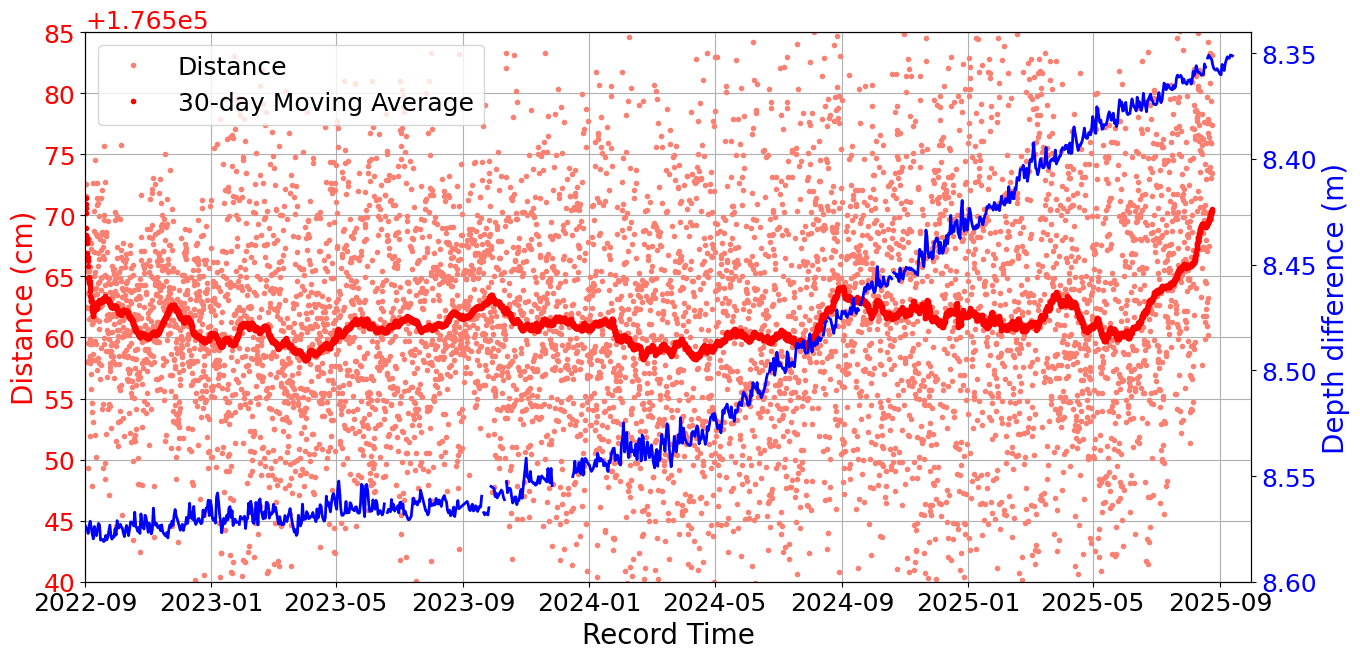

In [250]:
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})

fig, ax1 = plt.subplots(figsize=(14, 7))

# Left axis: Distance
ax1.plot(R2503_2504['Record Time'], R2503_2504['Calculated Distance (m)']*100, 
         '.', label="Distance", color='salmon')
ax1.plot(R2503_2504['Record Time'], R2503_2504['Moving Average'],
         'r.', label="30-day Moving Average")
ax1.set_xlabel("Record Time")
ax1.set_ylabel("Distance (cm)", color='red')
ax1.set_ylim(176540, 176585)
ax1.tick_params(axis='y', labelcolor='red')
ax1.grid(True)
ax1.legend(loc='upper left')

# Right axis: Depth Difference
ax2 = ax1.twinx()
ax2.plot(df_1day["time"], df_1day["depth_m_no_out"],
         label="Depth Difference", linewidth=2, color='blue')
ax2.set_ylabel("Depth difference (m)", color='blue')
ax2.set_ylim(8.34, 8.6)
ax2.invert_yaxis()
ax2.tick_params(axis='y', labelcolor='blue')
#ax2.legend(loc='upper right')

# Set common x-axis limits
ax1.set_xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
             pd.Timestamp(2025, 10, 1, tz="UTC"))

#plt.title("West -> Central Distance and Depth Difference (F-E)")
plt.tight_layout()
plt.show()

In [251]:
import numpy as np
import pandas as pd

def scatter_4h_two_numbers(df, time_col="Record Time", dist_m_col="Calculated Distance (m)"):
    t = pd.to_datetime(df[time_col], utc=True, errors="coerce")
    x_cm = pd.to_numeric(df[dist_m_col], errors="coerce") * 100.0
    s = pd.Series(x_cm.values, index=t).dropna().sort_index()

    # regular 4-hour grid
    x4 = s.resample("4H").median()

    # 4-hour lag = 1 sample
    diffs = (x4.shift(-1) - x4).dropna()
    rms_diff = float(np.sqrt(np.mean(diffs.values**2)))
    sigma_1 = float(rms_diff / np.sqrt(2.0))

    return int(diffs.size), rms_diff, sigma_1

n, rms4, sig1 = scatter_4h_two_numbers(R2503_2504)

print(f"R2503-2504 (4h): n={n}")
print(f"  RMS pairwise difference (Δd, 4h) = {rms4:.3f} cm")
print(f"  Equivalent 1-sample scatter (1σ) = {sig1:.3f} cm  (RMS/√2)")


R2503-2504 (4h): n=6462
  RMS pairwise difference (Δd, 4h) = 11.015 cm
  Equivalent 1-sample scatter (1σ) = 7.789 cm  (RMS/√2)


In [252]:
import numpy as np
import pandas as pd

def _series_distance_cm(df, time_col="Record Time",
                        dist_m_col="Calculated Distance (m)",
                        dist_cm_col=None):
    t = pd.to_datetime(df[time_col], utc=True, errors="coerce")
    if dist_cm_col is not None and dist_cm_col in df.columns:
        x_cm = pd.to_numeric(df[dist_cm_col], errors="coerce")
    else:
        x_cm = pd.to_numeric(df[dist_m_col], errors="coerce") * 100.0  # m -> cm
    s = pd.Series(x_cm.values, index=t).dropna().sort_index()
    return s

def std_30day_bins_using_median_length(
    df,
    time_col="Record Time",
    dist_m_col="Calculated Distance (m)",
    dist_cm_col=None,
    bin_days=30,
    min_n=10
):
    """
    Uses median baseline length from the data:
      L_med_km = median(Calculated Distance (m)) / 1000

    Computes:
      - std within each 30-day bin (cm)
      - average std across bins (cm)
      - cm/km using L_med_km
    """
    s_cm = _series_distance_cm(df, time_col=time_col,
                               dist_m_col=dist_m_col, dist_cm_col=dist_cm_col)

    # median baseline length (robust) from the distance series
    L_med_m = float(np.nanmedian(s_cm.values / 100.0))  # cm -> m
    L_med_km = L_med_m / 1000.0

    grp = s_cm.resample(f"{bin_days}D")
    n_in_bin = grp.size()

    # sample std (ddof=1); require enough points per bin
    std_cm = grp.apply(lambda x: float(np.nanstd(x.values, ddof=1)) if x.size >= min_n else np.nan)

    bin_table = pd.DataFrame({
        "bin_start_utc": std_cm.index,
        "n_points": n_in_bin.values,
        "std_cm": std_cm.values,
        "std_cm_per_km": std_cm.values / L_med_km,
    })

    avg_std_cm = float(np.nanmean(bin_table["std_cm"].values))
    avg_std_cm_per_km = float(avg_std_cm / L_med_km)

    summary = {
        "median_baseline_km_used": float(L_med_km),
        "avg_30d_std_cm": avg_std_cm,
        "avg_30d_std_cm_per_km": avg_std_cm_per_km,
        "n_bins_used": int(np.sum(~np.isnan(bin_table["std_cm"].values))),
    }
    return bin_table, summary


# -----------------------------
# Run for your three baselines
# -----------------------------
datasets = {
    "NT-ET": R2504_2502,
    "WT-NT": R2503_2504,
    "WT-ET": R2503_2502,
}

bin_tables = {}
summaries = []

for name, df in datasets.items():
    bins, summ = std_30day_bins_using_median_length(
        df,
        time_col="Record Time",
        dist_m_col="Calculated Distance (m)",
        bin_days=30,
        min_n=10
    )
    bin_tables[name] = bins
    summaries.append({"baseline": name, **summ})

summary_df = pd.DataFrame(summaries).set_index("baseline")
print(summary_df)

# Optional: inspect per-bin results
# print(bin_tables["NT-ET"].head(10))


          median_baseline_km_used  avg_30d_std_cm  avg_30d_std_cm_per_km  \
baseline                                                                   
NT-ET                    1.642137        6.360825               3.873505   
WT-NT                    1.765614        9.108808               5.159004   
WT-ET                    3.260262       15.695223               4.814099   

          n_bins_used  
baseline               
NT-ET              36  
WT-NT              37  
WT-ET              37  


In [253]:
import numpy as np
import pandas as pd

# --- prep ---
df = R2503_2504[['Record Time','Calculated Distance (m)']].dropna().copy()
df = df.rename(columns={'Calculated Distance (m)':'distance_m'})
df['Record Time'] = pd.to_datetime(df['Record Time'])
df = df.sort_values('Record Time').set_index('Record Time')

# 30-day windows: mean and std within each window
binned = (
    df.groupby(pd.Grouper(freq='30D'))
      .agg(distance_mean_m=('distance_m','mean'),
           distance_std_m =('distance_m','std'),
           count          =('distance_m','size'))
      .reset_index()
)

# keep reasonable windows
binned = binned[binned['count'] >= 10].copy()

# --- Precision metrics ---
# Absolute precision in mm (optional, for reference)
binned['precision_abs_mm'] = binned['distance_std_m'] * 1000.0

# Relative precision in ppm (optional) and cm/km (requested)
binned['precision_ppm']      = 1e6 * (binned['distance_std_m'] / binned['distance_mean_m'])
binned['precision_cm_per_km'] = binned['precision_ppm'] / 10.0     # == 1e5 * std/mean

# Summaries you can report
median_cm_per_km = binned['precision_cm_per_km'].median()
q25 = binned['precision_cm_per_km'].quantile(0.25)
q75 = binned['precision_cm_per_km'].quantile(0.75)

print(f"30-day precision (median): {median_cm_per_km:.2f} cm/km")
print(f"IQR: {q25:.2f}–{q75:.2f} cm/km over {len(binned)} windows")


30-day precision (median): 5.21 cm/km
IQR: 4.61–5.73 cm/km over 37 windows


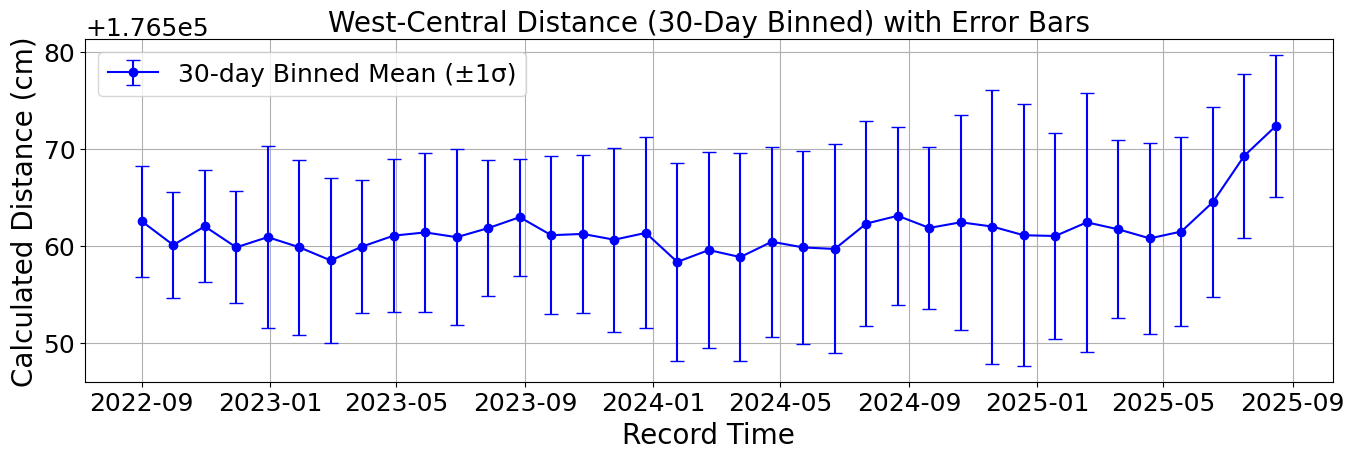

In [254]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'Record Time' is in datetime format
R2503_2504['Record Time'] = pd.to_datetime(R2503_2504['Record Time'])

# Remove any NaN values in 'Calculated Distance (m)'
R2503_2504.dropna(subset=['Calculated Distance (m)'], inplace=True)

# Group data into 30-day bins and calculate mean and standard deviation
binned_data = R2503_2504.resample('30D', on='Record Time').agg({
    'Calculated Distance (m)': ['mean', 'std']
})

# Rename columns for clarity
binned_data.columns = ['Mean Distance', 'Std Dev']

# Convert index (which is now the start of each 30-day bin) to a column for plotting
binned_data = binned_data.reset_index()

# Convert mean values to cm to match original scaling
binned_data['Mean Distance'] *= 100
binned_data['Std Dev'] *= 100

# Plot the binned mean values with error bars (std dev)
plt.figure(figsize=(14, 5))
plt.errorbar(
    binned_data['Record Time'], 
    binned_data['Mean Distance'], 
    yerr=binned_data['Std Dev'], 
    fmt='o-', color='blue', label="30-day Binned Mean (±1σ)", capsize=5
)

plt.title("West-Central Distance (30-Day Binned) with Error Bars")
plt.xlabel("Record Time")
plt.ylabel("Calculated Distance (cm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.rcParams.update({'font.size': 14})
plt.show()


In [255]:
R2503_2502 = R2503_2502.dropna(axis=1, how='all')
#R2503_2502.to_pickle("R2503_2502.pkl")
R2503_2502

,Record Time,BSL,Retrieval Time,Node Ref,UID,RangeNode Ref,RangeAddress,Range(ms),TAT(ms),Interpolated Sound Speed,Calculated Distance (m),Interpolated Harmonic Velocity,Harmonic Distance (m),Moving Average
0,2022-08-31 16:30:00,BSL,9/3/23 18:22,West,6874,East,2502,4556.569,160.0,1483.171257,3260.432385,1484.005599,3262.266507,326043.238505
1,2022-08-31 20:30:00,BSL,9/3/23 18:22,West,6874,East,2502,4556.602,160.0,1483.171257,3260.456857,1484.005599,3262.290993,326044.462121
2,2022-09-01 00:30:00,BSL,9/3/23 18:22,West,6874,East,2502,4556.621,160.0,1483.171257,3260.470947,1484.005599,3262.305091,326045.339664
3,2022-09-01 04:30:00,BSL,9/3/23 18:22,West,6874,East,2502,4556.549,160.0,1483.171257,3260.417553,1484.005599,3262.251667,326044.443581
4,2022-09-01 08:30:00,BSL,9/3/23 18:22,West,6874,East,2502,4556.464,160.0,1483.171257,3260.354519,1484.005599,3262.188596,326042.645236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6485,2025-08-23 12:30:00,BSL,2025/08/24 08:42:20,West,6874,East,2502,4556.607,160.0,1483.273557,3260.685452,1484.046517,3262.384653,326051.821891
6486,2025-08-23 16:30:00,BSL,2025/08/24 08:42:20,West,6874,East,2502,4556.677,160.0,1483.273557,3260.737366,1484.046517,3262.436594,326051.900369
6487,2025-08-23 20:30:00,BSL,2025/08/24 08:42:20,West,6874,East,2502,4556.505,160.0,1483.273557,3260.609805,1484.046517,3262.308966,326052.016745
6488,2025-08-24 00:30:00,BSL,2025/08/24 08:42:20,West,6874,East,2502,4556.683,160.0,1483.273557,3260.741816,1484.046517,3262.441047,326052.139297


In [256]:
R2503_2504 = R2503_2504.dropna(axis=1, how='all')
#R2503_2504.to_pickle("R2503_2504.pkl")
R2503_2504

,Record Time,BSL,Retrieval Time,Node Ref,UID,RangeNode Ref,RangeAddress,Range(ms),TAT(ms),Interpolated Sound Speed,Calculated Distance (m),Interpolated Harmonic Velocity,Harmonic Distance (m),Moving Average
0,2022-09-01 12:30:00,BSL,9/3/23 18:22,West,6874,North,2504,2700.297,320.0,1483.598301,1765.702292,1484.4788,1766.750217,176570.229242
1,2022-09-01 16:30:00,BSL,9/3/23 18:22,West,6874,North,2504,2700.315,320.0,1483.598301,1765.715645,1484.4781,1766.762744,176570.896862
2,2022-09-01 20:30:00,BSL,9/3/23 18:22,West,6874,North,2504,2700.328,320.0,1483.598301,1765.725288,1484.4851,1766.780725,176571.440848
3,2022-09-02 00:30:00,BSL,9/3/23 18:22,West,6874,North,2504,2700.267,320.0,1483.598301,1765.680038,1484.5160,1766.772223,176570.581597
4,2022-09-02 04:30:00,BSL,9/3/23 18:22,West,6874,North,2504,2700.193,320.0,1483.598301,1765.625145,1484.4880,1766.683973,176568.968184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,2025-08-23 12:30:00,BSL,2025/08/24 08:42:20,West,6874,South,2504,2700.098,320.0,1483.769879,1765.758860,1484.5676,1766.708188,176570.282311
6493,2025-08-23 16:30:00,BSL,2025/08/24 08:42:20,West,6874,South,2504,2700.098,320.0,1483.769879,1765.758860,1484.5676,1766.708188,176570.343774
6494,2025-08-23 20:30:00,BSL,2025/08/24 08:42:20,West,6874,South,2504,2700.065,320.0,1483.769879,1765.734378,1484.5676,1766.683692,176570.324225
6495,2025-08-24 00:30:00,BSL,2025/08/24 08:42:20,West,6874,South,2504,2700.196,320.0,1483.769879,1765.831565,1484.5676,1766.780932,176570.370365


## 2502 to west and central

In [257]:
del(filtered_bsl_2503_copy)
del(filtered_bsl_2504_copy)

In [258]:
import pandas as pd
import numpy as np

# Extract DataFrames based on the 'RangeAddress' column values
bsl_dfs = df_dict['2502']['BSL']
bsl_dfs['RangeAddress'] = bsl_dfs['RangeAddress'].astype(int).astype(str)
bsl_dfs['Range(ms)'] = pd.to_numeric(bsl_dfs['Range(ms)'], errors='coerce')
bsl_df['TAT(ms)'] = pd.to_numeric(bsl_df['TAT(ms)'], errors='coerce')
bsl_2503_dfs = bsl_dfs[bsl_dfs['RangeAddress'] == '2503'].copy()
bsl_2504_dfs = bsl_dfs[bsl_dfs['RangeAddress'] == '2504'].copy()

# Calculate the IQR for the 'Range(ms)' column in bsl_2502_df
Q1 = bsl_2503_dfs['Range(ms)'].quantile(0.25)
Q3 = bsl_2503_dfs['Range(ms)'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
filtered_bsl_2503_dfs = bsl_2503_dfs[(bsl_2503_dfs['Range(ms)'] >= 4636.2) & (bsl_2503_dfs['Range(ms)'] <= 4638)]
outside_values_df2 = bsl_2503_dfs[(bsl_2503_dfs['Range(ms)'] < 4636.2) & (bsl_2503_dfs['Range(ms)'] > 4638)]

# Convert the 'Range(ms)' column to numeric for plotting
bsl_2503_dfs['Range(ms)'] = pd.to_numeric(bsl_2503_dfs['Range(ms)'], errors='coerce')
bsl_2503_dfs['TAT(ms)'] = pd.to_numeric(bsl_2503_dfs['TAT(ms)'], errors='coerce')
Q1 = bsl_2504_dfs['Range(ms)'].quantile(0.25)
Q3 = bsl_2504_dfs['Range(ms)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

filtered_bsl_2504_dfs = bsl_2504_dfs[(bsl_2504_dfs['Range(ms)'] >= 2400)]
outside_values_df2 = bsl_2504_dfs[(bsl_2504_dfs['Range(ms)'] < 2400)]

bsl_2504_dfs['Range(ms)'] = pd.to_numeric(bsl_2504_dfs['Range(ms)'], errors='coerce')
bsl_2504_dfs['TAT(ms)'] = pd.to_numeric(bsl_2504_dfs['TAT(ms)'], errors='coerce')

filtered_bsl_2503_copy = filtered_bsl_2503_dfs.copy()
filtered_bsl_2504_copy = filtered_bsl_2504_dfs.copy()

ensure_datetime(filtered_bsl_2503_copy, 'Record Time')
ensure_datetime(harmonic_mean_dfs['2502_2503'], 'Record Time')

# Interpolation for 2503
filtered_bsl_2503_copy['Interpolated Sound Speed'] = np.interp(
    filtered_bsl_2503_copy['Record Time'].astype(np.int64),
    harmonic_df_dict['2502_2503']['Record Time'].view(np.int64),
    harmonic_df_dict['2502_2503']['HMean']
)

filtered_bsl_2503_copy['Calculated Distance (m)'] = filtered_bsl_2503_copy['Interpolated Sound Speed'] * ((filtered_bsl_2503_copy['Range(ms)']-pd.to_numeric(filtered_bsl_2503_copy['TAT(ms)'])) / 2000)

filtered_bsl_2503_copy = apply_tilt_correction(
    filtered_bsl_2503_copy, "2502-2503", baseline_perturb
)

R2502_2503 = filtered_bsl_2503_copy

#----------------------------------------------------------------------------------------------------------

# Interpolation for 2504
ensure_datetime(filtered_bsl_2504_copy, 'Record Time')
ensure_datetime(harmonic_df_dict['2502_2504'], 'Record Time')

filtered_bsl_2504_copy['Interpolated Sound Speed'] = np.interp(
    filtered_bsl_2504_copy['Record Time'].astype(np.int64),
    harmonic_df_dict['2502_2504']['Record Time'].view(np.int64),
    harmonic_df_dict['2502_2504']['HMean']
)

filtered_bsl_2504_copy['Calculated Distance (m)'] = filtered_bsl_2504_copy['Interpolated Sound Speed'] * ((filtered_bsl_2504_copy['Range(ms)']-pd.to_numeric(filtered_bsl_2504_copy['TAT(ms)'])) / 2000)

filtered_bsl_2504_copy = apply_tilt_correction(
    filtered_bsl_2504_copy, "2504-2502", baseline_perturb
)
##    Now we do this for central

R2502_2504 = filtered_bsl_2504_copy

/tmp/ipykernel_1893829/1507283314.py:57: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column_name] = pd.to_datetime(df[column_name])
/tmp/ipykernel_1893829/1507283314.py:57: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column_name] = pd.to_datetime(df[column_name])


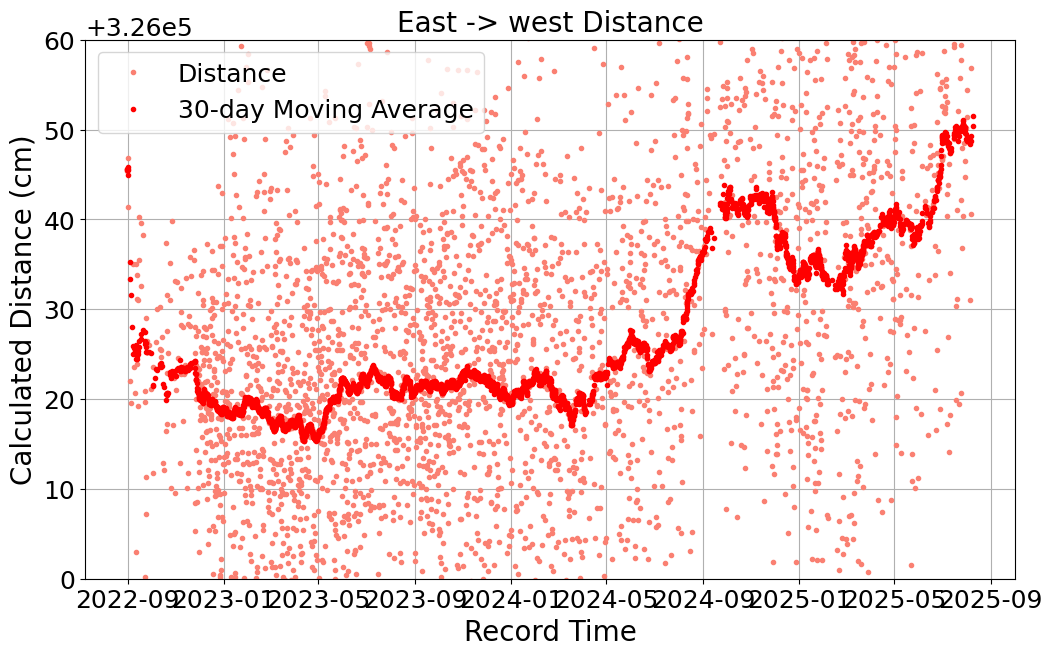

In [259]:
import matplotlib.pyplot as plt
import pandas as pd

# Sort by time to ensure proper rolling calculations
R2502_2503 = R2502_2503.sort_values(by='Record Time')

# Set 'Record Time' as the index
R2502_2503 = R2502_2503.set_index('Record Time')

# Compute 30-day rolling mean
R2502_2503['Moving Average'] = (
    R2502_2503['Calculated Distance (m)']
    .rolling('30D')
    .mean()
) * 100

# Reset index for plotting
R2502_2503 = R2502_2503.reset_index()
plt.figure(figsize=(12, 7))
plt.plot(R2502_2503['Record Time'], R2502_2503['Calculated Distance (m)']*100, '.', label="Distance", color='salmon')

# Plot moving average
plt.plot(R2502_2503['Record Time'], 
         R2502_2503['Moving Average'],'r.', 
         label="30-day Moving Average")

# Formatting
plt.xlabel("Record Time")
plt.ylabel("Calculated Distance (cm)")
plt.legend()
plt.ylim(326000,326060)
plt.title("East -> west Distance")
plt.grid(True)
plt.show()


In [260]:
import pandas as pd

# Ensure 'Record Time' is in datetime format
R2502_2503['Record Time'] = pd.to_datetime(R2502_2503['Record Time'])

# Sort by time to ensure proper rolling calculations
R2502_2503 = R2502_2503.sort_values(by='Record Time')

# Set 'Record Time' as the index
R2502_2503 = R2502_2503.set_index('Record Time')

# Compute 30-day rolling mean
R2502_2503['Moving Average'] = (
    R2502_2503['Calculated Distance (m)']
    .rolling('30D')
    .mean()
) * 100

# Reset index
R2502_2503 = R2502_2503.reset_index()

# Create DataFrame with the scatter plot data
scatter_data = pd.DataFrame({
    'Record Time': R2502_2503['Record Time'],
    'Distance (cm)': R2502_2503['Calculated Distance (m)'] * 100,
    'Moving Average (cm)': R2502_2503['Moving Average']
})

# Save to CSV
scatter_data.to_csv('EW_distance.csv', index=False)
print("Data saved to 'EW_distance.csv'")


Data saved to 'EW_distance.csv'


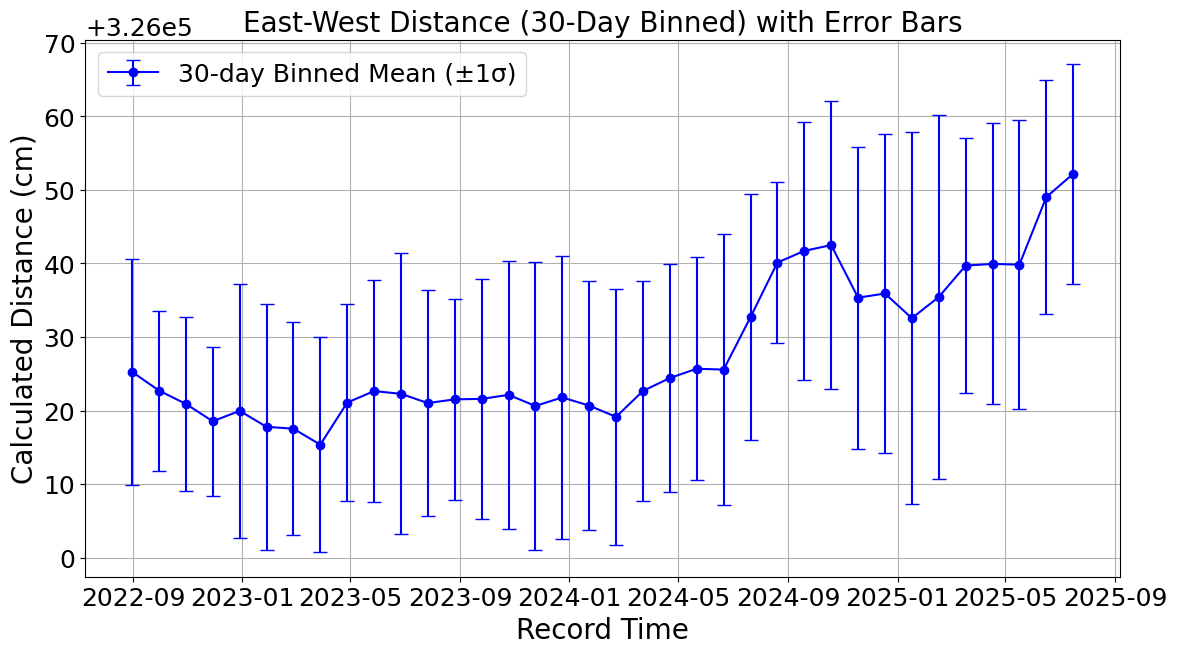

In [261]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'Record Time' is in datetime format
R2502_2503['Record Time'] = pd.to_datetime(R2502_2503['Record Time'])

# Remove any NaN values in 'Calculated Distance (m)'
R2502_2503.dropna(subset=['Calculated Distance (m)'], inplace=True)

# Group data into 30-day bins and calculate mean and standard deviation
binned_data = R2502_2503.resample('30D', on='Record Time').agg({
    'Calculated Distance (m)': ['mean', 'std']
})

# Rename columns for clarity
binned_data.columns = ['Mean Distance', 'Std Dev']

# Convert index (which is now the start of each 30-day bin) to a column for plotting
binned_data = binned_data.reset_index()

# Convert mean values to cm to match original scaling
binned_data['Mean Distance'] *= 100
binned_data['Std Dev'] *= 100

# Plot the binned mean values with error bars (std dev)
plt.figure(figsize=(12, 7))
plt.errorbar(
    binned_data['Record Time'], 
    binned_data['Mean Distance'], 
    yerr=binned_data['Std Dev'], 
    fmt='o-', color='blue', label="30-day Binned Mean (±1σ)", capsize=5
)

plt.title("East-West Distance (30-Day Binned) with Error Bars")
plt.xlabel("Record Time")
plt.ylabel("Calculated Distance (cm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.rcParams.update({'font.size': 14})
plt.show()


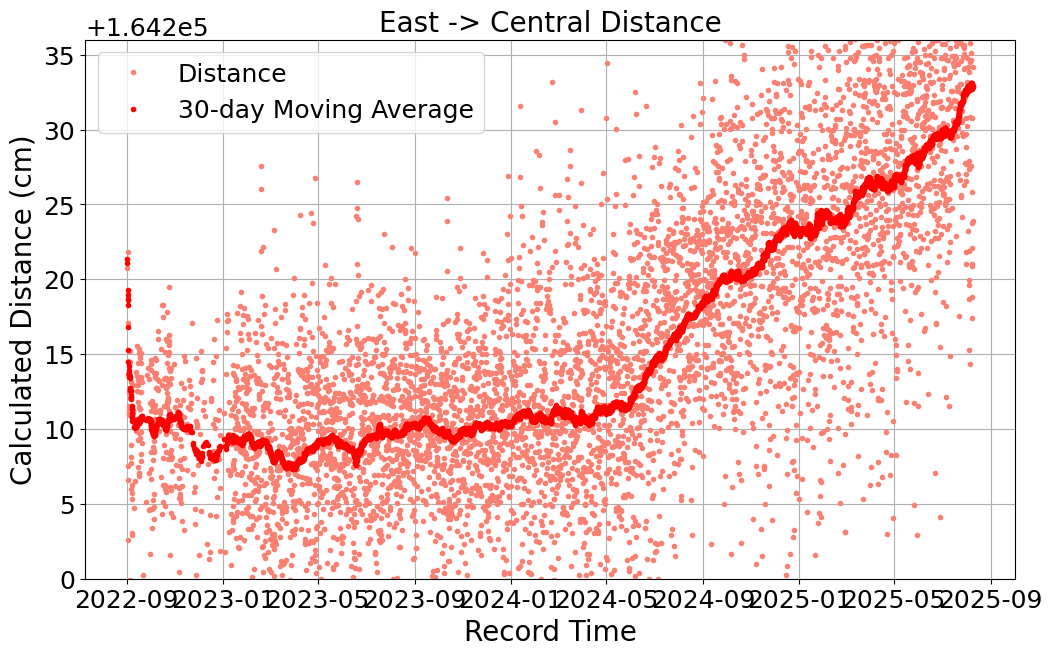

In [262]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'Record Time' is in datetime format
#R2502_2504['Record Time'] = pd.to_datetime(R2502_2504['Record Time'])

# Sort by time to ensure proper rolling calculations
R2502_2504 = R2502_2504.sort_values(by='Record Time')

# Set 'Record Time' as the index
R2502_2504 = R2502_2504.set_index('Record Time')

# Compute 30-day rolling mean
R2502_2504['Moving Average'] = (
    R2502_2504['Calculated Distance (m)']
    .rolling('30D')
    .mean()
) * 100

# Reset index for plotting
R2502_2504 = R2502_2504.reset_index()
plt.figure(figsize=(12, 7))
plt.plot(R2502_2504['Record Time'], R2502_2504['Calculated Distance (m)']*100, '.', label="Distance", color='salmon')

# Plot moving average
plt.plot(R2502_2504['Record Time'], 
         R2502_2504['Moving Average'],'r.', 
         label="30-day Moving Average")

# Formatting
plt.xlabel("Record Time")
plt.ylabel("Calculated Distance (cm)")
plt.legend()
plt.ylim(164200,164236)
plt.title("East -> Central Distance")
plt.grid(True)
plt.show()


In [263]:
import pandas as pd

# Ensure 'Record Time' is in datetime format
R2502_2504['Record Time'] = pd.to_datetime(R2502_2504['Record Time'])

# Sort by time to ensure proper rolling calculations
R2502_2504 = R2502_2504.sort_values(by='Record Time')

# Set 'Record Time' as the index
R2502_2504 = R2502_2504.set_index('Record Time')

# Compute 30-day rolling mean
R2502_2504['Moving Average'] = (
    R2502_2504['Calculated Distance (m)']
    .rolling('30D')
    .mean()
) * 100

# Reset index
R2502_2504 = R2502_2504.reset_index()

# Create DataFrame with the scatter plot data
scatter_data = pd.DataFrame({
    'Record Time': R2502_2504['Record Time'],
    'Distance (cm)': R2502_2504['Calculated Distance (m)'] * 100,
    'Moving Average (cm)': R2502_2504['Moving Average']
})

# Save to CSV
scatter_data.to_csv('EC_distance.csv', index=False)
print("Data saved to 'EC_distance.csv'")



Data saved to 'EC_distance.csv'


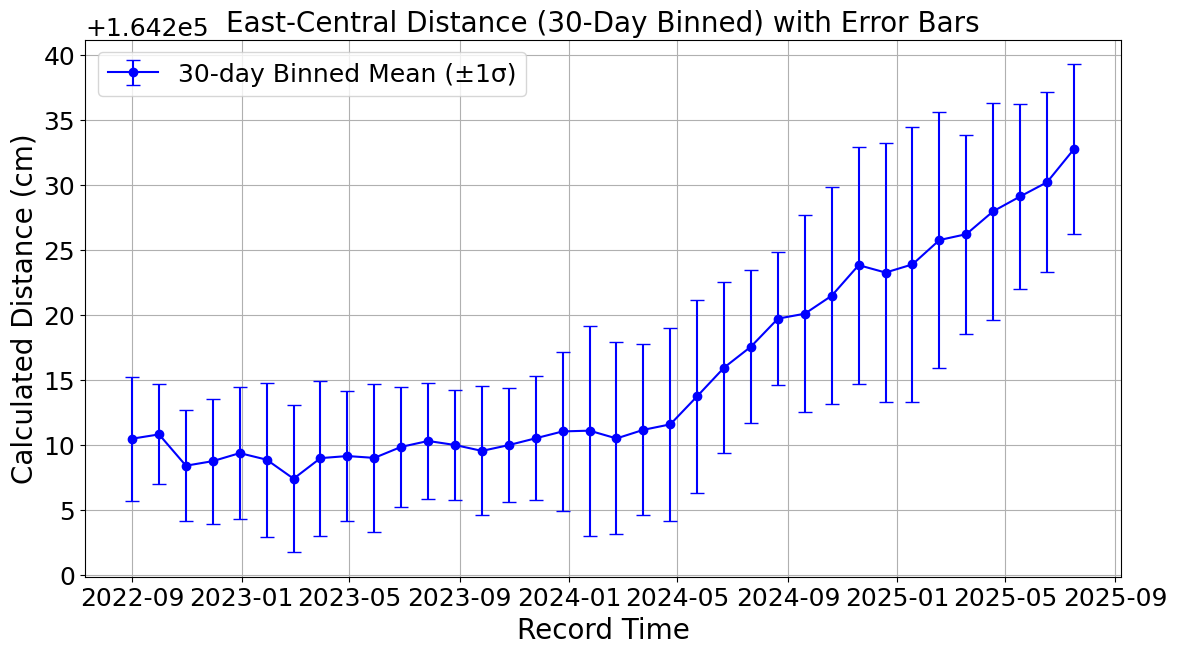

In [264]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'Record Time' is in datetime format
R2502_2504['Record Time'] = pd.to_datetime(R2502_2504['Record Time'])

# Remove any NaN values in 'Calculated Distance (m)'
R2502_2504.dropna(subset=['Calculated Distance (m)'], inplace=True)

# Group data into 30-day bins and calculate mean and standard deviation
binned_data = R2502_2504.resample('30D', on='Record Time').agg({
    'Calculated Distance (m)': ['mean', 'std']
})

# Rename columns for clarity
binned_data.columns = ['Mean Distance', 'Std Dev']

# Convert index (which is now the start of each 30-day bin) to a column for plotting
binned_data = binned_data.reset_index()

# Convert mean values to cm to match original scaling
binned_data['Mean Distance'] *= 100
binned_data['Std Dev'] *= 100

# Plot the binned mean values with error bars (std dev)
plt.figure(figsize=(12, 7))
plt.errorbar(
    binned_data['Record Time'], 
    binned_data['Mean Distance'], 
    yerr=binned_data['Std Dev'], 
    fmt='o-', color='blue', label="30-day Binned Mean (±1σ)", capsize=5
)

plt.title("East-Central Distance (30-Day Binned) with Error Bars")
plt.xlabel("Record Time")
plt.ylabel("Calculated Distance (cm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.rcParams.update({'font.size': 14})
plt.show()


In [265]:
R2502_2503 = R2502_2503.dropna(axis=1, how='all')
#R2502_2503.to_pickle("R2502_2503.pkl")
R2502_2503

,Record Time,BSL,Retrieval Time,Node Ref,UID,RangeNode Ref,RangeAddress,Range(ms),TAT(ms),Interpolated Sound Speed,Calculated Distance (m),Moving Average
0,2022-08-31 15:30:00,BSL,9/3/23 13:22,East,6870,West,2503,4636.601,240,1483.171257,3260.456116,326045.611579
1,2022-08-31 19:30:00,BSL,9/3/23 13:22,East,6870,West,2503,4636.598,240,1483.171257,3260.453891,326045.500341
2,2022-08-31 23:30:00,BSL,9/3/23 13:22,East,6870,West,2503,4636.601,240,1483.171257,3260.456116,326045.537420
3,2022-09-01 03:30:00,BSL,9/3/23 13:22,East,6870,West,2503,4636.617,240,1483.171257,3260.467981,326045.852594
4,2022-09-01 07:30:00,BSL,9/3/23 13:22,East,6870,West,2503,4636.544,240,1483.171257,3260.413845,326044.958983
...,...,...,...,...,...,...,...,...,...,...,...,...
3396,2025-08-05 15:30:00,BSL,2025/08/09 09:23:53,East,6870,West,2503,4636.294,240.0,1483.208627,3260.310594,326048.375911
3397,2025-08-06 07:30:00,BSL,2025/08/09 09:23:53,East,6870,West,2503,4636.313,240.0,1483.245747,3260.406281,326048.742888
3398,2025-08-07 11:30:00,BSL,2025/08/09 09:23:54,East,6870,West,2503,4636.450,240.0,1483.273557,3260.569015,326049.301665
3399,2025-08-08 23:30:00,BSL,2025/08/09 09:24:01,East,6870,West,2503,4636.688,240.0,1483.273557,3260.745524,326050.358877


In [266]:
R2502_2504 = R2502_2504.dropna(axis=1, how='all')
#R2502_2504.to_pickle("R2502_2504.pkl")
R2502_2504

,Record Time,BSL,Retrieval Time,Node Ref,UID,RangeNode Ref,RangeAddress,Range(ms),TAT(ms),Interpolated Sound Speed,Calculated Distance (m),Moving Average
0,2022-09-01 15:30:00,BSL,9/3/23 13:22,East,6870,North,2504,2533.136,320,1484.060266,1642.213600,164221.360023
1,2022-09-01 19:30:00,BSL,9/3/23 13:22,East,6870,North,2504,2533.128,320,1484.060266,1642.207664,164221.063211
2,2022-09-01 23:30:00,BSL,9/3/23 13:22,East,6870,North,2504,2533.032,320,1484.060266,1642.136429,164218.589777
3,2022-09-02 03:30:00,BSL,9/3/23 13:22,East,6870,North,2504,2533.104,320,1484.060266,1642.189855,164218.688715
4,2022-09-02 07:30:00,BSL,9/3/23 13:22,East,6870,North,2504,2533.142,320,1484.060266,1642.218052,164219.312020
...,...,...,...,...,...,...,...,...,...,...,...,...
5871,2025-08-08 11:30:00,BSL,2025/08/09 09:23:54,East,6870,South,2504,2533.172,320.0,1484.057920,1642.237717,164232.801930
5872,2025-08-08 15:30:00,BSL,2025/08/09 09:23:54,East,6870,South,2504,2533.149,320.0,1484.057920,1642.220651,164232.738590
5873,2025-08-08 19:30:00,BSL,2025/08/09 09:23:54,East,6870,South,2504,2533.200,320.0,1484.057920,1642.258494,164232.817945
5874,2025-08-08 23:30:00,BSL,2025/08/09 09:24:01,East,6870,South,2504,2533.174,320.0,1484.057920,1642.239201,164232.829424


In [267]:
import pandas as pd

# Load the baseline perturbation data
# Assuming baseline_perturb is already loaded with columns: '2504-2502_dL', '2504-2503_dL', '2502-2503_dL'
# and has datetime index

# Ensure baseline_perturb index is datetime
if not isinstance(baseline_perturb.index, pd.DatetimeIndex):
    baseline_perturb.index = pd.to_datetime(baseline_perturb.index)

# Define the mapping between perturbations and baseline files
corrections = {
    '2504-2502_dL': ['CE_distance.csv', 'EC_distance.csv'],
    '2504-2503_dL': ['CW_distance.csv', 'WC_distance.csv'],
    '2502-2503_dL': ['EW_distance.csv', 'WE_distance.csv']
}

# Apply corrections to each file
for perturb_col, file_list in corrections.items():
    for filename in file_list:
        # Load the distance file
        df = pd.read_csv(filename)
        df['Record Time'] = pd.to_datetime(df['Record Time'])
        
        # Create a dataframe with perturbation values
        perturb_df = baseline_perturb[[perturb_col]].reset_index()
        perturb_df.columns = ['Record Time', 'perturbation']
        
        # Merge using merge_asof for nearest time match
        df_sorted = df.sort_values('Record Time')
        perturb_sorted = perturb_df.sort_values('Record Time')
        
        df_merged = pd.merge_asof(df_sorted, perturb_sorted, 
                                  on='Record Time', 
                                  direction='nearest',
                                  tolerance=pd.Timedelta('1H'))
        
        # Fill any remaining NaN perturbations with 0 (no correction)
        df_merged['perturbation'] = df_merged['perturbation'].fillna(0)
        
        # Add perturbation to distance (convert dL from meters to cm)
        df_merged['Distance (cm)'] = df_merged['Distance (cm)'] + (df_merged['perturbation'] * 100)
        
        # Set index for rolling calculation
        df_merged = df_merged.set_index('Record Time').sort_index()
        
        # Recalculate 30-day moving average with corrected distances
        df_merged['Moving Average (cm)'] = (
            df_merged['Distance (cm)']
            .rolling('30D')
            .mean()
        )
        
        # Reset index and keep only needed columns
        df_merged = df_merged[['Distance (cm)', 'Moving Average (cm)']].reset_index()
        
        # Save to new filename with _corrected suffix
        output_filename = filename.replace('.csv', '_corrected.csv')
        df_merged.to_csv(output_filename, index=False)
        print(f"Corrected and saved: {output_filename}")
        print(f"  - Applied perturbation range: {df_merged['Distance (cm)'].min():.2f} to {df_merged['Distance (cm)'].max():.2f} cm")

print("\nAll files corrected and saved with new names!")

Corrected and saved: CE_distance_corrected.csv
  - Applied perturbation range: 164184.80 to 164263.82 cm
Corrected and saved: EC_distance_corrected.csv
  - Applied perturbation range: 164184.13 to 164263.97 cm
Corrected and saved: CW_distance_corrected.csv
  - Applied perturbation range: 176521.02 to 176612.59 cm
Corrected and saved: WC_distance_corrected.csv
  - Applied perturbation range: 176520.67 to 176614.81 cm
Corrected and saved: EW_distance_corrected.csv
  - Applied perturbation range: 325943.15 to 326087.26 cm
Corrected and saved: WE_distance_corrected.csv
  - Applied perturbation range: 325951.01 to 326091.32 cm

All files corrected and saved with new names!


In [268]:
df_merged

,Record Time,Distance (cm),Moving Average (cm)
0,2022-08-31 16:30:00,326040.528594,326040.528594
1,2022-08-31 20:30:00,326042.970416,326041.749505
2,2022-09-01 00:30:00,326044.381314,326042.626775
3,2022-09-01 04:30:00,326039.035868,326041.729048
4,2022-09-01 08:30:00,326032.727407,326039.928720
...,...,...,...
6485,2025-08-23 12:30:00,326065.907081,326049.181571
6486,2025-08-23 16:30:00,326071.096575,326049.260052
6487,2025-08-23 20:30:00,326058.341652,326049.376425
6488,2025-08-24 00:30:00,326071.538899,326049.498938


In [269]:
df_merged

,Record Time,Distance (cm),Moving Average (cm)
0,2022-08-31 16:30:00,326040.528594,326040.528594
1,2022-08-31 20:30:00,326042.970416,326041.749505
2,2022-09-01 00:30:00,326044.381314,326042.626775
3,2022-09-01 04:30:00,326039.035868,326041.729048
4,2022-09-01 08:30:00,326032.727407,326039.928720
...,...,...,...
6485,2025-08-23 12:30:00,326065.907081,326049.181571
6486,2025-08-23 16:30:00,326071.096575,326049.260052
6487,2025-08-23 20:30:00,326058.341652,326049.376425
6488,2025-08-24 00:30:00,326071.538899,326049.498938


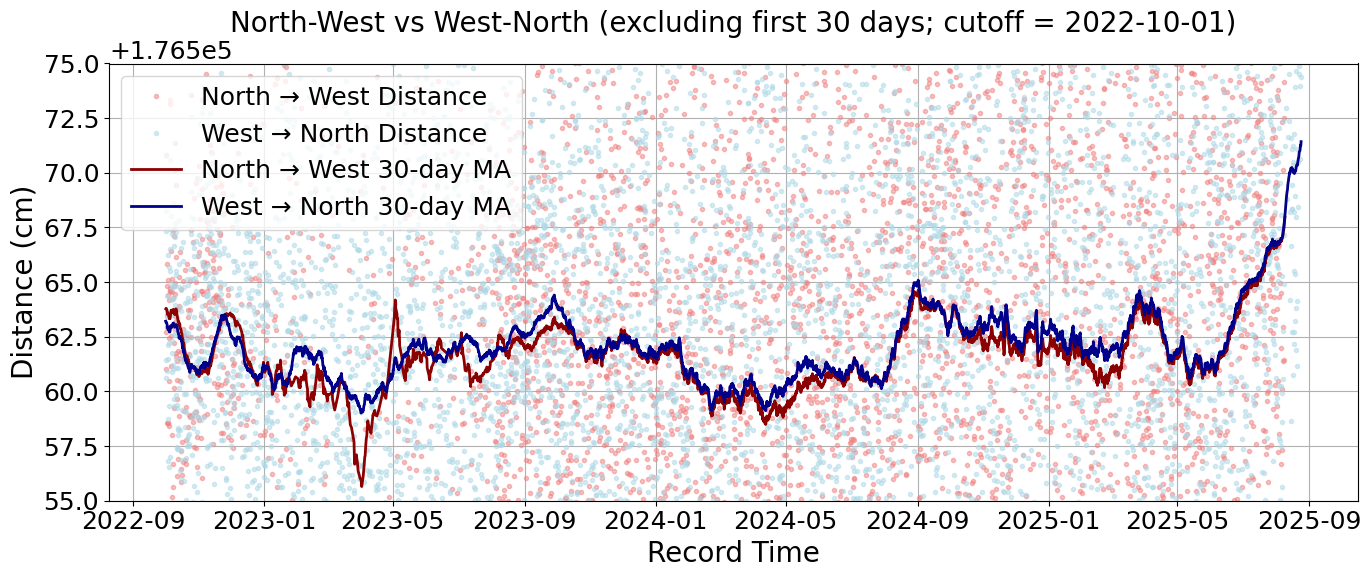

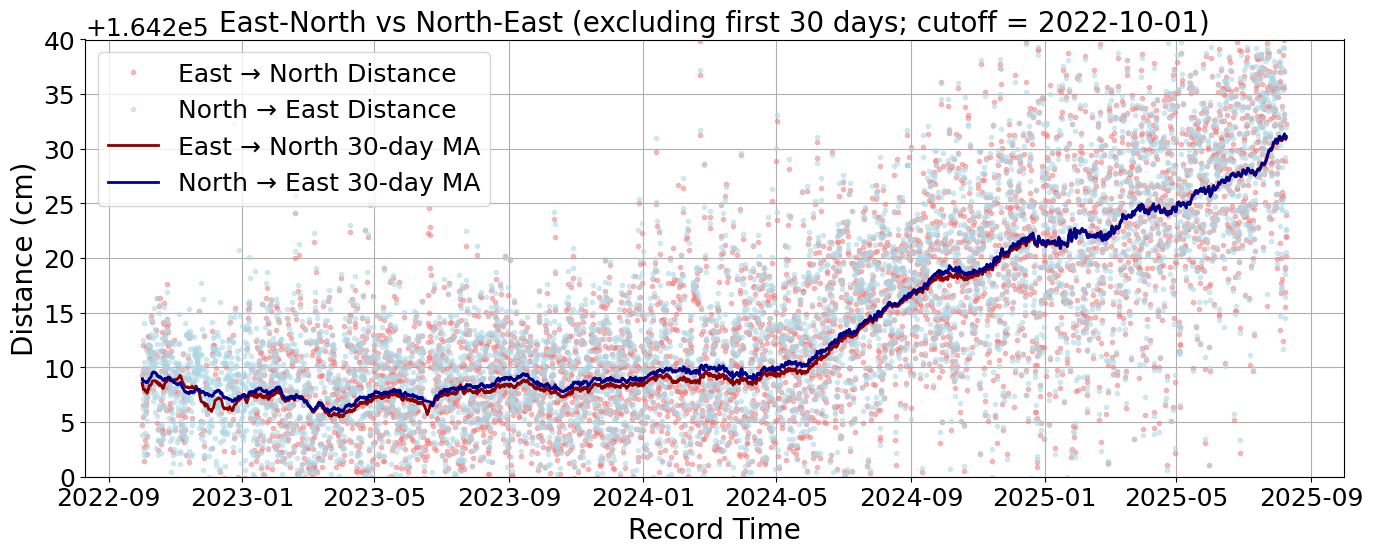

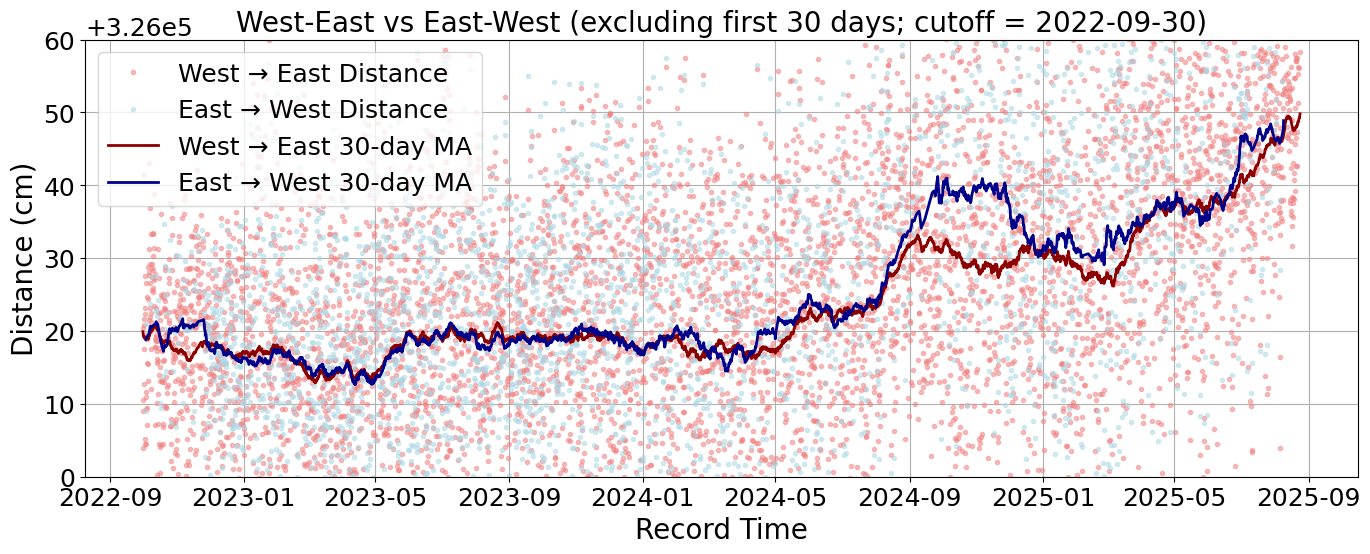

In [271]:
import pandas as pd
import matplotlib.pyplot as plt

EXCLUDE_DAYS = 30  # exclude the first N days of data for each baseline pair

# Define bidirectional baseline pairs with proper labels and y-limits
baseline_pairs = [
    ('CW_distance_corrected.csv', 'WC_distance_corrected.csv',
     'North → West', 'West → North', 'North-West vs West-North',
     (176555, 176575)),  # y-limits for CW/WC
    ('EC_distance_corrected.csv', 'CE_distance_corrected.csv',
     'East → North', 'North → East', 'East-North vs North-East',
     (164200, 164240)),  # y-limits for EC/CE
    ('WE_distance_corrected.csv', 'EW_distance_corrected.csv',
     'West → East', 'East → West', 'West-East vs East-West',
     (326000, 326060))   # y-limits for WE/EW
]

for file1, file2, label1, label2, title, ylim in baseline_pairs:
    # Load first baseline
    df1 = pd.read_csv(file1)
    df1['Record Time'] = pd.to_datetime(df1['Record Time'], errors='coerce')
    df1 = df1.dropna(subset=['Record Time']).sort_values('Record Time')

    # Load second baseline
    df2 = pd.read_csv(file2)
    df2['Record Time'] = pd.to_datetime(df2['Record Time'], errors='coerce')
    df2 = df2.dropna(subset=['Record Time']).sort_values('Record Time')

    # Define the cutoff: earliest time across the pair + EXCLUDE_DAYS
    t0 = min(df1['Record Time'].min(), df2['Record Time'].min())
    cutoff = t0 + pd.Timedelta(days=EXCLUDE_DAYS)

    # Filter out first 30 days
    df1p = df1[df1['Record Time'] >= cutoff].copy()
    df2p = df2[df2['Record Time'] >= cutoff].copy()

    # Colors (lighter for scatter, darker for moving average)
    color1_light = 'lightcoral'
    color1_dark = 'darkred'
    color2_light = 'lightblue'
    color2_dark = 'darkblue'

    # Plot
    plt.figure(figsize=(14, 6))

    # Scatter plots
    plt.plot(df1p['Record Time'], df1p['Distance (cm)'], '.',
             color=color1_light, label=f"{label1} Distance", alpha=0.5)
    plt.plot(df2p['Record Time'], df2p['Distance (cm)'], '.',
             color=color2_light, label=f"{label2} Distance", alpha=0.5)

    # Moving average lines
    plt.plot(df1p['Record Time'], df1p['Moving Average (cm)'],
             color=color1_dark, linewidth=2, label=f"{label1} 30-day MA")
    plt.plot(df2p['Record Time'], df2p['Moving Average (cm)'],
             color=color2_dark, linewidth=2, label=f"{label2} 30-day MA")

    # Formatting
    plt.xlabel("Record Time")
    plt.ylabel("Distance (cm)")
    plt.title(f"{title} (excluding first {EXCLUDE_DAYS} days; cutoff = {cutoff.date()})")
    plt.ylim(ylim)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


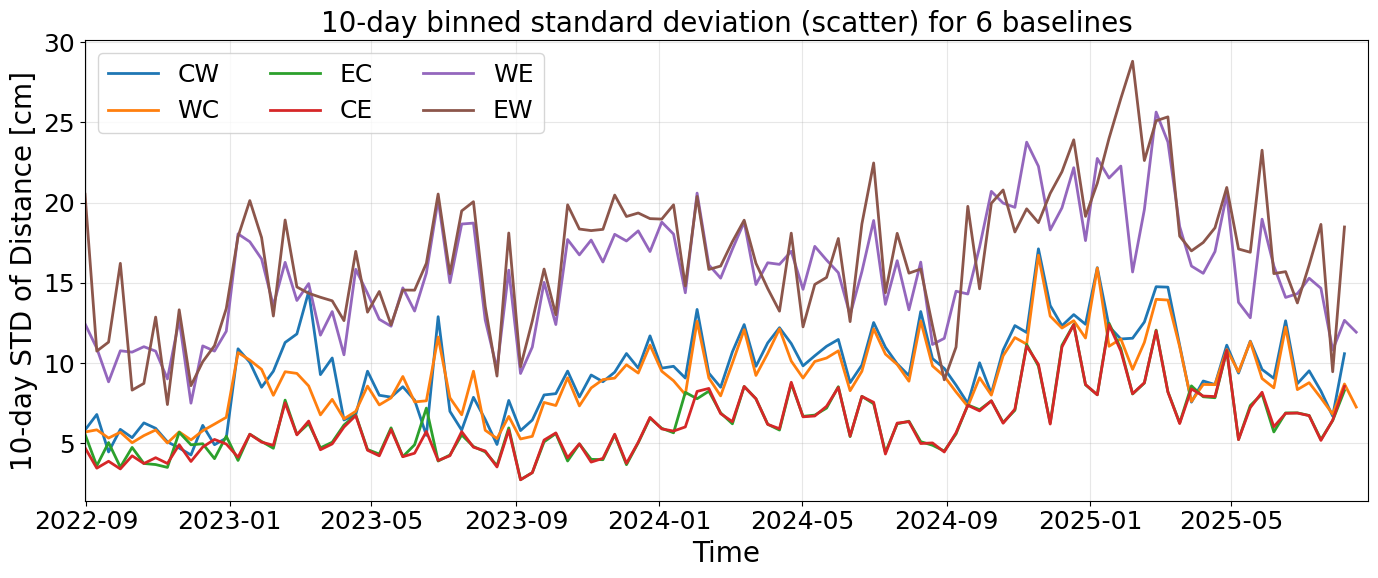

In [272]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Settings ---
files = {
    "CW": "CW_distance_corrected.csv",
    "WC": "WC_distance_corrected.csv",
    "EC": "EC_distance_corrected.csv",
    "CE": "CE_distance_corrected.csv",
    "WE": "WE_distance_corrected.csv",
    "EW": "EW_distance_corrected.csv",
}

BIN = "10D"

# If you want the scatter around the moving average instead of raw distance:
USE_RESIDUALS = False  # True -> std of (Distance - Moving Average)

# Optional: require at least N points in a bin to keep that std
MIN_POINTS_PER_BIN = 2  # set higher (e.g., 10) if you want

# --- Load all data first (so bins align across baselines) ---
dfs = {}
all_times = []

for name, fn in files.items():
    df = pd.read_csv(fn)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    # Choose what the "scatter" is
    if USE_RESIDUALS:
        if "Moving Average (cm)" not in df.columns:
            raise ValueError(f"{fn} missing 'Moving Average (cm)' needed for residuals.")
        df["scatter"] = df["Distance (cm)"] - df["Moving Average (cm)"]
    else:
        df["scatter"] = df["Distance (cm)"]

    dfs[name] = df
    all_times.append(df["Record Time"].min())
    all_times.append(df["Record Time"].max())

global_start = min(all_times).floor("D")
global_end   = max(all_times).ceil("D")

# --- Compute 10-day binned std for each baseline ---
std_series = {}
count_series = {}

for name, df in dfs.items():
    s = df.set_index("Record Time")["scatter"].dropna()

    # Align bins for all series using the same origin
    g = s.resample(BIN, origin=global_start)

    std = g.std()
    cnt = g.count()

    # Apply min-points filter
    std[cnt < MIN_POINTS_PER_BIN] = pd.NA

    std_series[name] = std
    count_series[name] = cnt

# Combine into one dataframe (handy if you want to save/export)
std_df = pd.DataFrame(std_series).sort_index()

# --- Plot ---
plt.figure(figsize=(14, 6))
for name in std_df.columns:
    plt.plot(std_df.index, std_df[name], linewidth=2, label=name)

ylabel = "10-day STD of (Distance - Moving Average) [cm]" if USE_RESIDUALS else "10-day STD of Distance [cm]"
plt.ylabel(ylabel)
plt.xlabel("Time")
plt.title("10-day binned standard deviation (scatter) for 6 baselines")
plt.grid(True, alpha=0.3)
plt.legend(ncol=3)
plt.xlim(global_start, global_end)
plt.tight_layout()
plt.show()

# Optional: save the binned std to CSV
# std_df.to_csv("baseline_10day_std.csv", index=True)


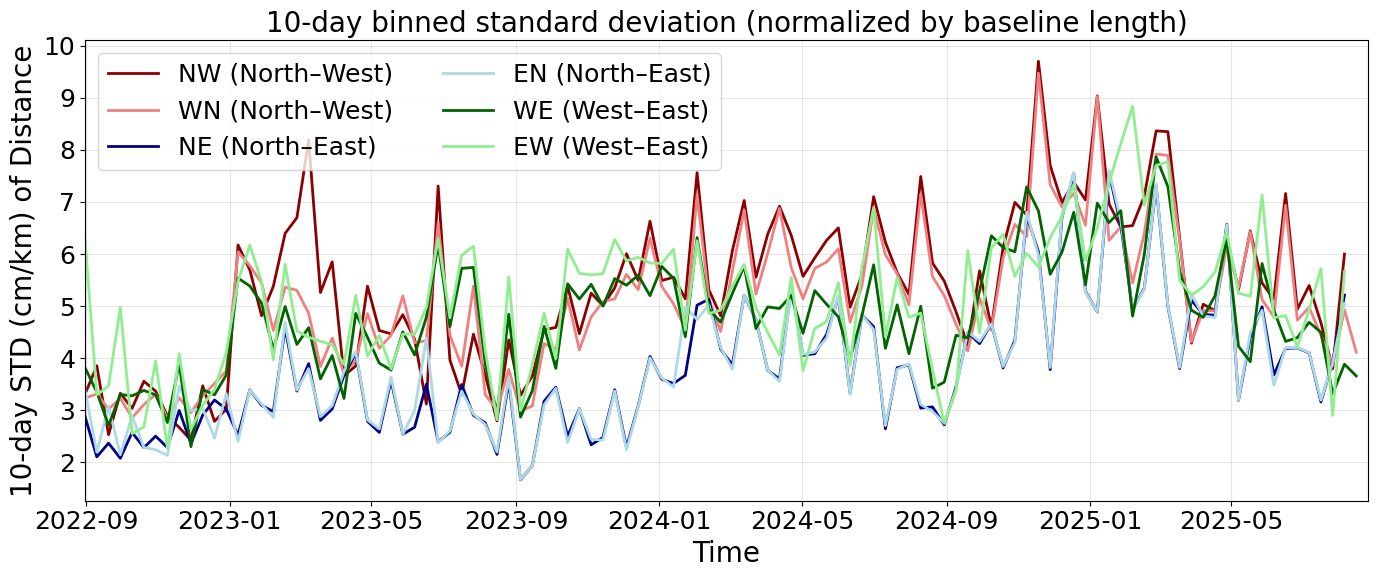

In [273]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Files ---
files = {
    "NW": "CW_distance_corrected.csv",
    "WN": "WC_distance_corrected.csv",
    "NE": "CE_distance_corrected.csv",
    "EN": "EC_distance_corrected.csv",
    "WE": "WE_distance_corrected.csv",
    "EW": "EW_distance_corrected.csv",
}

# --- Baseline lengths (km) ---
length_km = {
    "NW": 1.765, "WN": 1.765,
    "NE": 1.642, "EN": 1.642,
    "WE": 3.26,  "EW": 3.26,
}

# --- Pairs + colors (light/dark per pair) ---
pairs = [
    ("NW", "WN", "North–West",  "lightcoral", "darkred"),
    ("NE", "EN", "North–East",  "lightblue",  "darkblue"),
    ("WE", "EW", "West–East",     "lightgreen", "darkgreen"),
]

BIN = "10D"
USE_RESIDUALS = False   # True -> std of (Distance - Moving Average)
MIN_POINTS_PER_BIN = 2  # bins with fewer points get dropped

# --- Load all data (for common time/bin alignment) ---
dfs = {}
tmins, tmaxs = [], []

for name, fn in files.items():
    df = pd.read_csv(fn)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    if USE_RESIDUALS:
        if "Moving Average (cm)" not in df.columns:
            raise ValueError(f"{fn} missing 'Moving Average (cm)' needed for residuals.")
        df["scatter"] = df["Distance (cm)"] - df["Moving Average (cm)"]
    else:
        df["scatter"] = df["Distance (cm)"]

    dfs[name] = df
    tmins.append(df["Record Time"].min())
    tmaxs.append(df["Record Time"].max())

global_start = min(tmins).floor("D")
global_end   = max(tmaxs).ceil("D")

# --- Helper: 10-day STD normalized by baseline length (cm/km) ---
def ten_day_std_cm_per_km(df, L_km):
    s = df.set_index("Record Time")["scatter"].dropna()
    g = s.resample(BIN, origin=global_start)
    std_cm = g.std()
    cnt = g.count()
    std_cm[cnt < MIN_POINTS_PER_BIN] = pd.NA
    return std_cm / L_km  # cm/km

std_series = {name: ten_day_std_cm_per_km(dfs[name], length_km[name]) for name in dfs}

# --- Plot: all in one figure, light/dark within each pair ---
plt.figure(figsize=(14, 6))

for a, b, pair_label, light_c, dark_c in pairs:
    plt.plot(std_series[a].index, std_series[a].values,
             linewidth=2, color=dark_c, label=f"{a} ({pair_label})")
    plt.plot(std_series[b].index, std_series[b].values,
             linewidth=2, color=light_c, label=f"{b} ({pair_label})")

ylabel = "10-day STD (cm/km) of (Distance - MA)" if USE_RESIDUALS else "10-day STD (cm/km) of Distance"
plt.ylabel(ylabel)
plt.xlabel("Time")
plt.title("10-day binned standard deviation (normalized by baseline length)")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.xlim(global_start, global_end)
plt.tight_layout()
plt.show()

# Optional: save
# pd.DataFrame(std_series).sort_index().to_csv("baseline_10day_std_cm_per_km.csv")


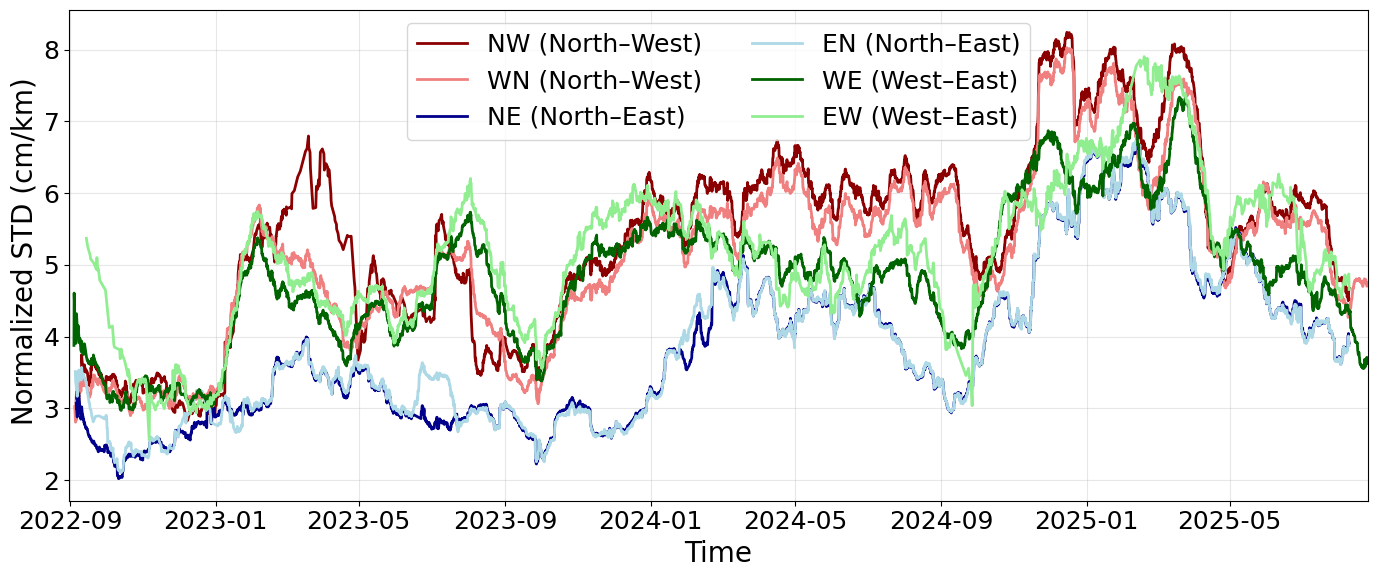

In [274]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Files ---
files = {
    "NW": "CW_distance_corrected.csv",
    "WN": "WC_distance_corrected.csv",
    "NE": "CE_distance_corrected.csv",
    "EN": "EC_distance_corrected.csv",
    "WE": "WE_distance_corrected.csv",
    "EW": "EW_distance_corrected.csv",
}

# --- Baseline lengths (km) ---
length_km = {
    "NW": 1.765, "WN": 1.765,
    "NE": 1.642, "EN": 1.642,
    "WE": 3.26,  "EW": 3.26,
}

# --- Pairs + colors (light/dark per pair) ---
pairs = [
    ("NW", "WN", "North–West",  "lightcoral", "darkred"),
    ("NE", "EN", "North–East",  "lightblue",  "darkblue"),
    ("WE", "EW", "West–East",   "lightgreen", "darkgreen"),
]

USE_RESIDUALS = False
WINDOW_DAYS = 30
MIN_POINTS_IN_WINDOW = 20  # number of samples (not days) required in the 30-day window

# --- Load all data (for common x-limits) ---
dfs = {}
tmins, tmaxs = [], []

for name, fn in files.items():
    df = pd.read_csv(fn)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    if USE_RESIDUALS:
        if "Moving Average (cm)" not in df.columns:
            raise ValueError(f"{fn} missing 'Moving Average (cm)' needed for residuals.")
        df["scatter"] = df["Distance (cm)"] - df["Moving Average (cm)"]
    else:
        df["scatter"] = df["Distance (cm)"]

    dfs[name] = df
    tmins.append(df["Record Time"].min())
    tmaxs.append(df["Record Time"].max())

global_start = min(tmins).floor("D")
global_end   = max(tmaxs).ceil("D")

def rolling_std_cm_per_km(df, L_km, window_days=30, min_pts=10):
    s = df.set_index("Record Time")["scatter"].dropna().sort_index()

    # FIX: collapse duplicate timestamps (mean is a safe default)
    s = s.groupby(level=0).mean()

    std_cm = s.rolling(f"{window_days}D", min_periods=min_pts).std()
    return std_cm / L_km  # cm/km

std_series = {
    name: rolling_std_cm_per_km(dfs[name], length_km[name],
                                window_days=WINDOW_DAYS,
                                min_pts=MIN_POINTS_IN_WINDOW)
    for name in dfs
}

# --- Plot ---
plt.figure(figsize=(14, 6))

for a, b, pair_label, light_c, dark_c in pairs:
    plt.plot(std_series[a].index, std_series[a].values,
             linewidth=2, color=dark_c, label=f"{a} ({pair_label})")
    plt.plot(std_series[b].index, std_series[b].values,
             linewidth=2, color=light_c, label=f"{b} ({pair_label})")

ylabel = (f"{WINDOW_DAYS} Normalized Standard Deviation (cm/km)"
          if USE_RESIDUALS else
          f" Normalized STD (cm/km)")
plt.ylabel(ylabel)
plt.xlabel("Time")
#plt.title(f"{WINDOW_DAYS}-day moving (rolling) standard deviation (normalized by baseline length)")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.xlim(global_start, global_end)
plt.tight_layout()
plt.show()


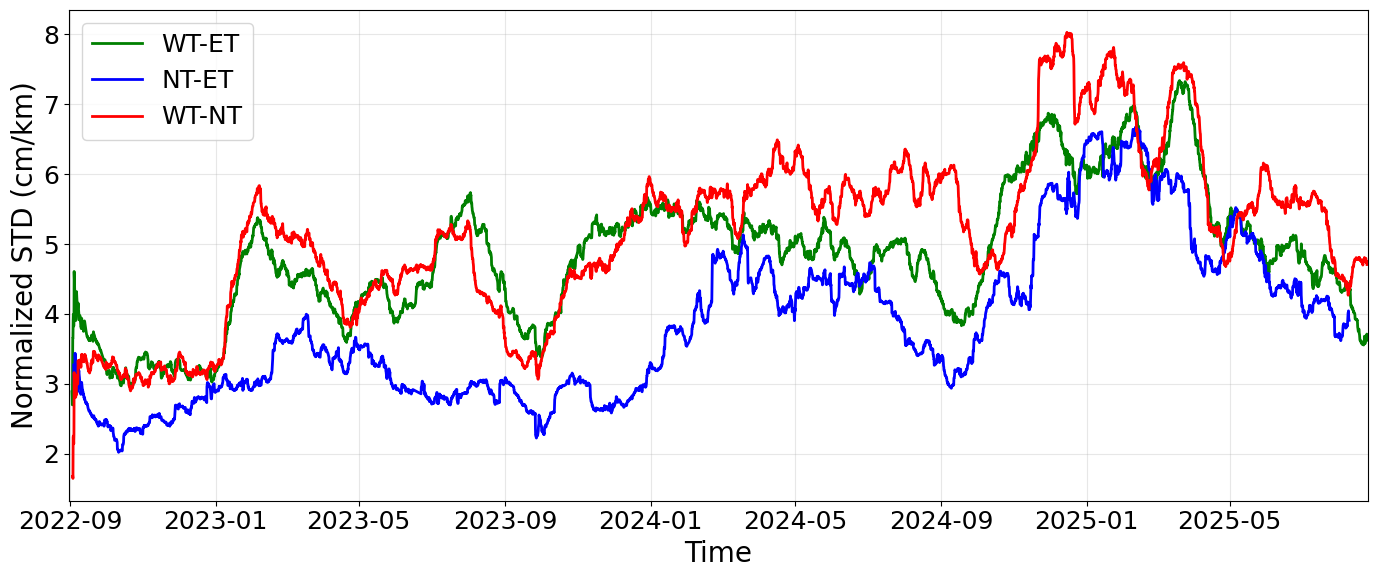

In [275]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Files: ONLY the three you want ---
files = {
    "WT-NT": "WC_distance_corrected.csv",
    "NT-ET": "CE_distance_corrected.csv",
    "WT-ET": "WE_distance_corrected.csv",
}

# --- Baseline lengths (km) ---
length_km = {
    "WT-NT": 1.765,
    "NT-ET": 1.642,
    "WT-ET": 3.26,
}

# --- Plot colors ---
colors = {
    "WT-ET": "green",
    "NT-ET": "blue",
    "WT-NT": "red",
}

USE_RESIDUALS = False
WINDOW_DAYS = 30
MIN_POINTS_IN_WINDOW = 10  # samples required inside the 30-day window

# --- Load all data (for common x-limits) ---
dfs = {}
tmins, tmaxs = [], []

for name, fn in files.items():
    df = pd.read_csv(fn)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    if USE_RESIDUALS:
        if "Moving Average (cm)" not in df.columns:
            raise ValueError(f"{fn} missing 'Moving Average (cm)' needed for residuals.")
        df["scatter"] = df["Distance (cm)"] - df["Moving Average (cm)"]
    else:
        df["scatter"] = df["Distance (cm)"]

    dfs[name] = df
    tmins.append(df["Record Time"].min())
    tmaxs.append(df["Record Time"].max())

global_start = min(tmins).floor("D")
global_end   = max(tmaxs).ceil("D")

def rolling_std_cm_per_km(df, L_km, window_days=30, min_pts=10):
    s = df.set_index("Record Time")["scatter"].dropna().sort_index()

    # collapse duplicate timestamps (required for time-based rolling)
    s = s.groupby(level=0).mean()

    std_cm = s.rolling(f"{window_days}D", min_periods=min_pts).std()
    return std_cm / L_km  # cm/km

std_series = {
    name: rolling_std_cm_per_km(dfs[name], length_km[name],
                                window_days=WINDOW_DAYS,
                                min_pts=MIN_POINTS_IN_WINDOW)
    for name in dfs
}

# --- Plot ---
plt.figure(figsize=(14, 6))

for name in ["WT-ET", "NT-ET", "WT-NT"]:
    plt.plot(std_series[name].index, std_series[name].values,
             linewidth=2, color=colors[name], label=name)

ylabel = (f"{WINDOW_DAYS}-day rolling STD (cm/km) of (Distance - MA)"
          if USE_RESIDUALS else
          f"Normalized STD (cm/km)")
plt.ylabel(ylabel)
plt.xlabel("Time")
#plt.title(f"{WINDOW_DAYS}-day moving (rolling) standard deviation (normalized by baseline length)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(global_start, global_end)
plt.tight_layout()
plt.show()


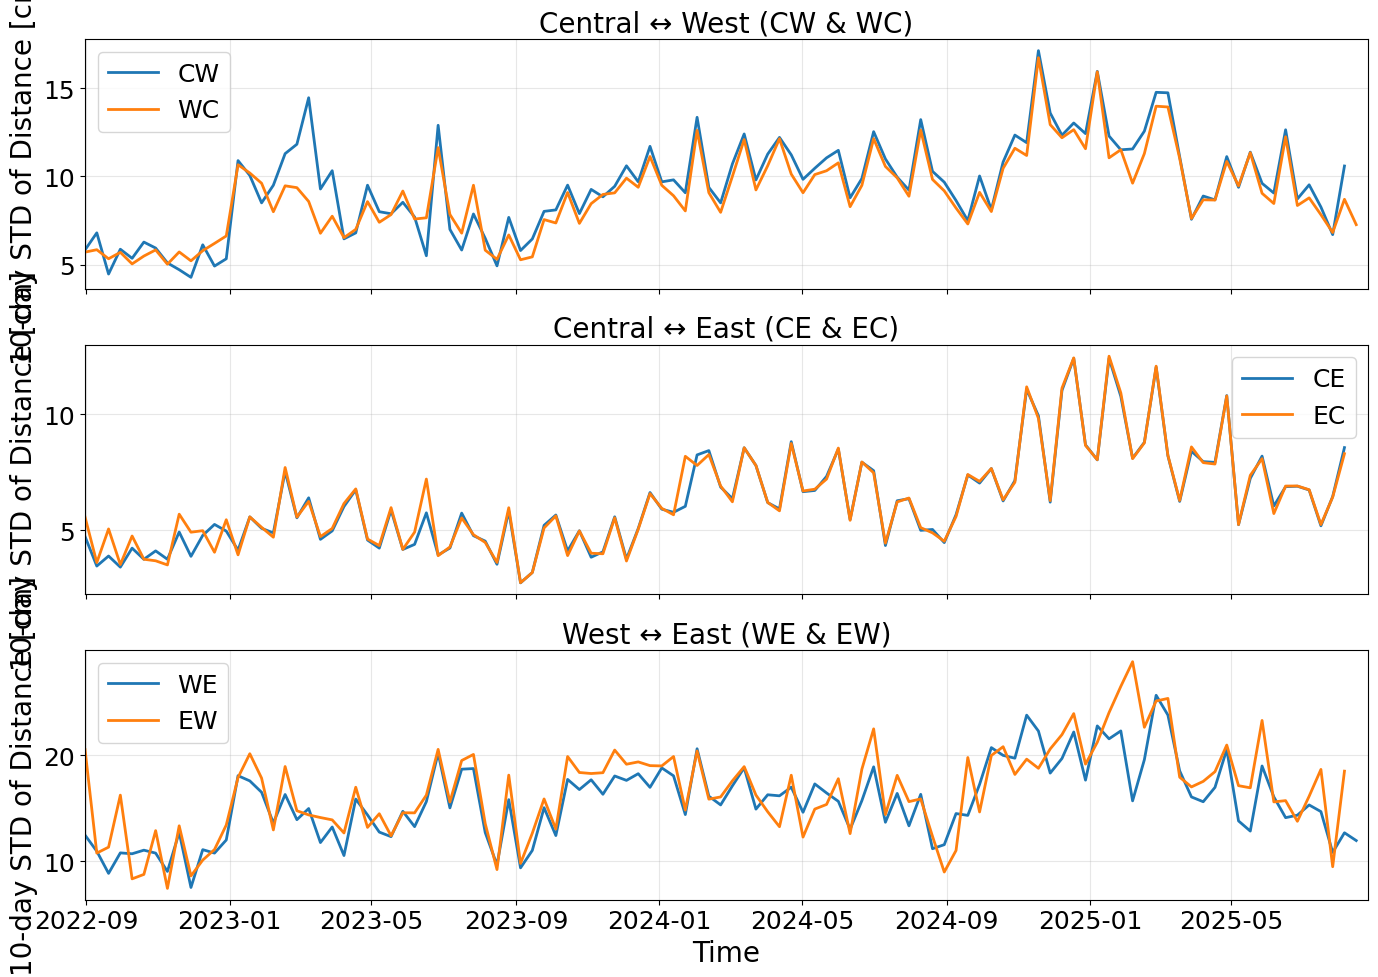

In [276]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Settings ---
files = {
    "CW": "CW_distance_corrected.csv",
    "WC": "WC_distance_corrected.csv",
    "CE": "CE_distance_corrected.csv",
    "EC": "EC_distance_corrected.csv",
    "WE": "WE_distance_corrected.csv",
    "EW": "EW_distance_corrected.csv",
}

pairs = [
    ("CW", "WC", "Central ↔ West (CW & WC)"),
    ("CE", "EC", "Central ↔ East (CE & EC)"),
    ("WE", "EW", "West ↔ East (WE & EW)"),
]

BIN = "10D"

# If you want std of scatter around the moving average instead of raw distance:
USE_RESIDUALS = False  # True -> std of (Distance - Moving Average)

MIN_POINTS_PER_BIN = 2  # bins with fewer points get dropped

# --- Load all data (for common bin alignment) ---
dfs = {}
tmins, tmaxs = [], []

for name, fn in files.items():
    df = pd.read_csv(fn)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    if USE_RESIDUALS:
        if "Moving Average (cm)" not in df.columns:
            raise ValueError(f"{fn} missing 'Moving Average (cm)' needed for residuals.")
        df["scatter"] = df["Distance (cm)"] - df["Moving Average (cm)"]
    else:
        df["scatter"] = df["Distance (cm)"]

    dfs[name] = df
    tmins.append(df["Record Time"].min())
    tmaxs.append(df["Record Time"].max())

global_start = min(tmins).floor("D")
global_end   = max(tmaxs).ceil("D")

# --- Helper to compute 10-day std time series ---
def ten_day_std(df):
    s = df.set_index("Record Time")["scatter"].dropna()
    g = s.resample(BIN, origin=global_start)
    std = g.std()
    cnt = g.count()
    std[cnt < MIN_POINTS_PER_BIN] = pd.NA
    return std

std_series = {name: ten_day_std(df) for name, df in dfs.items()}

# --- Plot: 3 subplots ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ylabel = "10-day STD of (Distance - MA) [cm]" if USE_RESIDUALS else "10-day STD of Distance [cm]"

for ax, (a, b, title) in zip(axes, pairs):
    ax.plot(std_series[a].index, std_series[a].values, linewidth=2, label=a)
    ax.plot(std_series[b].index, std_series[b].values, linewidth=2, label=b)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Time")
axes[-1].set_xlim(global_start, global_end)

plt.tight_layout()
plt.show()

# Optional: save all binned std values
# std_df = pd.DataFrame(std_series).sort_index()
# std_df.to_csv("baseline_10day_std.csv")


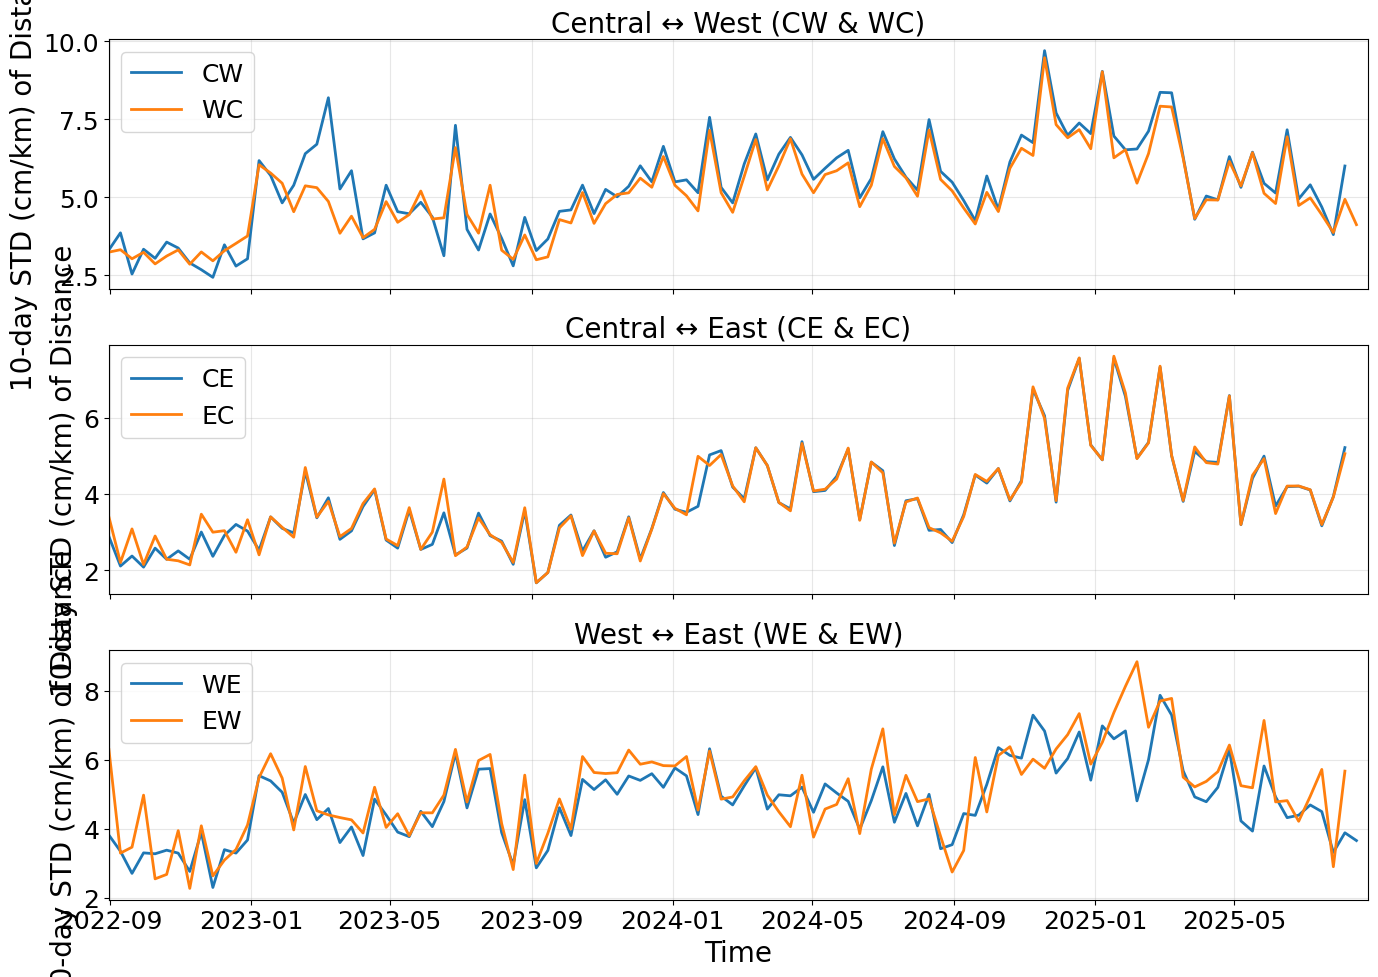

In [277]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Settings ---
files = {
    "CW": "CW_distance_corrected.csv",
    "WC": "WC_distance_corrected.csv",
    "CE": "CE_distance_corrected.csv",
    "EC": "EC_distance_corrected.csv",
    "WE": "WE_distance_corrected.csv",
    "EW": "EW_distance_corrected.csv",
}

pairs = [
    ("CW", "WC", "Central ↔ West (CW & WC)"),
    ("CE", "EC", "Central ↔ East (CE & EC)"),
    ("WE", "EW", "West ↔ East (WE & EW)"),
]

# Baseline lengths in km (given by you)
length_km = {
    "CW": 1.765, "WC": 1.765,
    "CE": 1.642, "EC": 1.642,
    "WE": 3.26,  "EW": 3.26,
}

BIN = "10D"

# If you want std of scatter around the moving average instead of raw distance:
USE_RESIDUALS = False  # True -> std of (Distance - Moving Average)

MIN_POINTS_PER_BIN = 2  # bins with fewer points get dropped

# --- Load all data (for common bin alignment) ---
dfs = {}
tmins, tmaxs = [], []

for name, fn in files.items():
    df = pd.read_csv(fn)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    if USE_RESIDUALS:
        if "Moving Average (cm)" not in df.columns:
            raise ValueError(f"{fn} missing 'Moving Average (cm)' needed for residuals.")
        df["scatter"] = df["Distance (cm)"] - df["Moving Average (cm)"]
    else:
        df["scatter"] = df["Distance (cm)"]

    dfs[name] = df
    tmins.append(df["Record Time"].min())
    tmaxs.append(df["Record Time"].max())

global_start = min(tmins).floor("D")
global_end   = max(tmaxs).ceil("D")

# --- Helper: 10-day std, normalized by baseline length (cm/km) ---
def ten_day_std_cm_per_km(df, L_km):
    s = df.set_index("Record Time")["scatter"].dropna()
    g = s.resample(BIN, origin=global_start)

    std_cm = g.std()
    cnt = g.count()
    std_cm[cnt < MIN_POINTS_PER_BIN] = pd.NA

    return std_cm / L_km  # cm/km

std_series = {name: ten_day_std_cm_per_km(dfs[name], length_km[name]) for name in dfs}

# --- Plot: 3 subplots ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ylabel = "10-day STD (cm/km) of (Distance - MA)" if USE_RESIDUALS else "10-day STD (cm/km) of Distance"

for ax, (a, b, title) in zip(axes, pairs):
    ax.plot(std_series[a].index, std_series[a].values, linewidth=2, label=a)
    ax.plot(std_series[b].index, std_series[b].values, linewidth=2, label=b)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Time")
axes[-1].set_xlim(global_start, global_end)

plt.tight_layout()
plt.show()

# Optional: save
# std_df = pd.DataFrame(std_series).sort_index()
# std_df.to_csv("baseline_10day_std_cm_per_km.csv")
